# Laboratorio 4 - Análisis de datos geoespaciales

##### Marco Carbajal - 23025
##### Carlos Angel   - 23010
##### Diego Monroy   - 23318

In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import truststore
import openeo



Conexión al API

In [ ]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


Áreas de interés y fechas

In [ ]:
lagos = {
    "Atitlan": {
        "bbox": {"west": -91.326256, "east": -91.07151, "south": 14.5948, "north": 14.750979},
        "fechas": ["2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17", "2025-11-21",
                   "2025-12-29", "2026-02-12", "2026-03-24", "2026-04-13", "2026-04-28",
                   "2026-07-22"],
    },
    "Amatitlan": {
        "bbox": {"west": -90.638065, "east": -90.512924, "south": 14.412347, "north": 14.493799},
        "fechas": ["2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24", "2026-01-08",
                   "2026-02-02", "2026-02-07", "2026-03-29", "2026-04-13", "2026-04-28",
                   "2026-06-19"],
    },
}

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

In [ ]:
# B03, B04 y B08 son nativas de 10 m; B05 es de 20 m y openEO la remuestrea a 10 m,
# así que se ve más fina pero no aporta detalle nuevo.
BANDAS = ["B03", "B04", "B05", "B08"]


def descargar(lago, fecha):
    ruta = f"{DATA_DIR}/{lago}_{fecha}.tif"
    if os.path.exists(ruta):
        return ruta

    fin = (pd.Timestamp(fecha) + pd.Timedelta("1D")).strftime("%Y-%m-%d")
    cubo = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=lagos[lago]["bbox"],
        temporal_extent=[fecha, fin],
        bands=BANDAS,
    )
    cubo = cubo.reduce_dimension(dimension="t", reducer="max")  # una sola imagen por fecha
    cubo = cubo.resample_spatial(resolution=10, projection="EPSG:32615")  # UTM 15N (Guatemala)
    cubo.download(ruta)
    return ruta


for lago, info in lagos.items():
    for fecha in info["fechas"]:
        ruta = descargar(lago, fecha)
        print(lago, fecha, f"{os.path.getsize(ruta) / 1e6:.1f} MB")

Atitlan 2025-01-18 30.1 MB
Atitlan 2025-04-13 30.3 MB
Atitlan 2025-05-13 31.9 MB
Atitlan 2025-07-17 30.9 MB
Atitlan 2025-11-21 30.2 MB
Atitlan 2025-12-29 30.5 MB
Atitlan 2026-02-12 30.9 MB
Atitlan 2026-03-24 31.2 MB
Atitlan 2026-04-13 32.0 MB
Atitlan 2026-04-28 32.3 MB
Atitlan 2026-07-22 32.2 MB
Amatitlan 2025-01-28 8.9 MB
Amatitlan 2025-04-15 8.9 MB
Amatitlan 2025-04-28 9.0 MB
Amatitlan 2025-11-24 8.8 MB
Amatitlan 2026-01-08 8.9 MB
Amatitlan 2026-02-02 8.9 MB
Amatitlan 2026-02-07 8.9 MB
Amatitlan 2026-03-29 9.1 MB
Amatitlan 2026-04-13 9.1 MB
Amatitlan 2026-04-28 9.1 MB
Amatitlan 2026-06-19 9.0 MB


Cálculo de los índices sobre cada imagen descargada:

In [ ]:
def nd(a, b):
    return (a - b) / (a + b)


def indices(lago, fecha):
    with rasterio.open(f"{DATA_DIR}/{lago}_{fecha}.tif") as src:
        datos = src.read().astype("float32")

    datos[datos <= 0] = np.nan  
    b03, b04, b05, b08 = datos / 10000  

    ndwi = nd(b03, b08)
    ndci = nd(b05, b04)
    return {
        "ndvi": nd(b08, b04),
        "ndwi": ndwi,
        "ndci": ndci,
        "chla": np.clip(826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071, 0, 500),  # ug/L
        "agua": ndwi > 0,
    }

Mapas de los tres índices para una fecha de cada lago

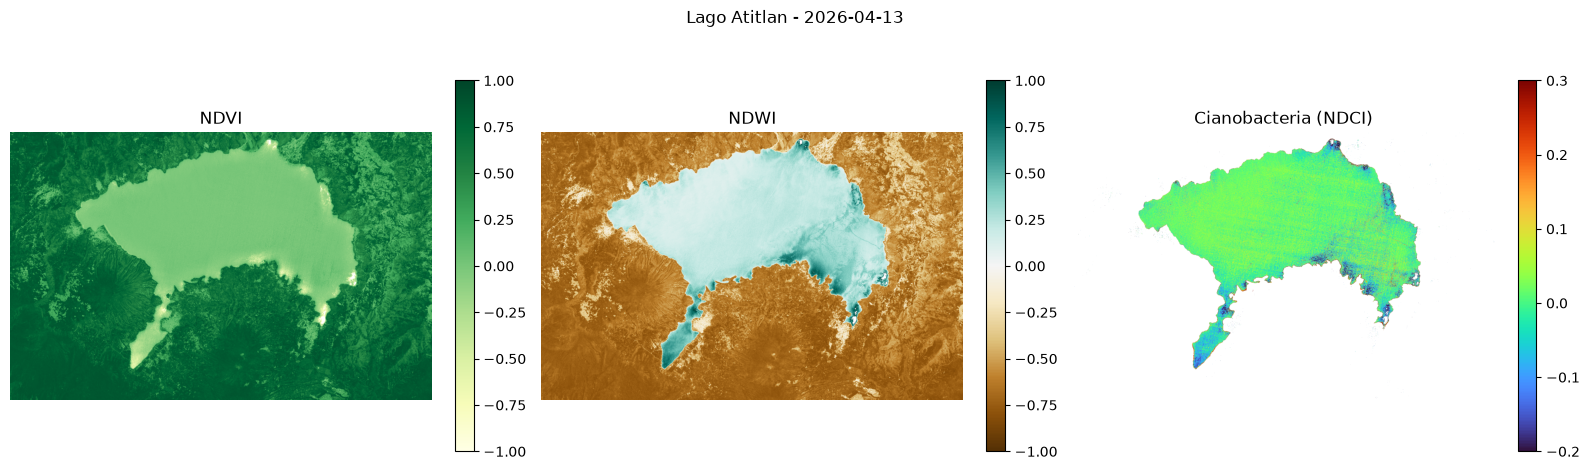

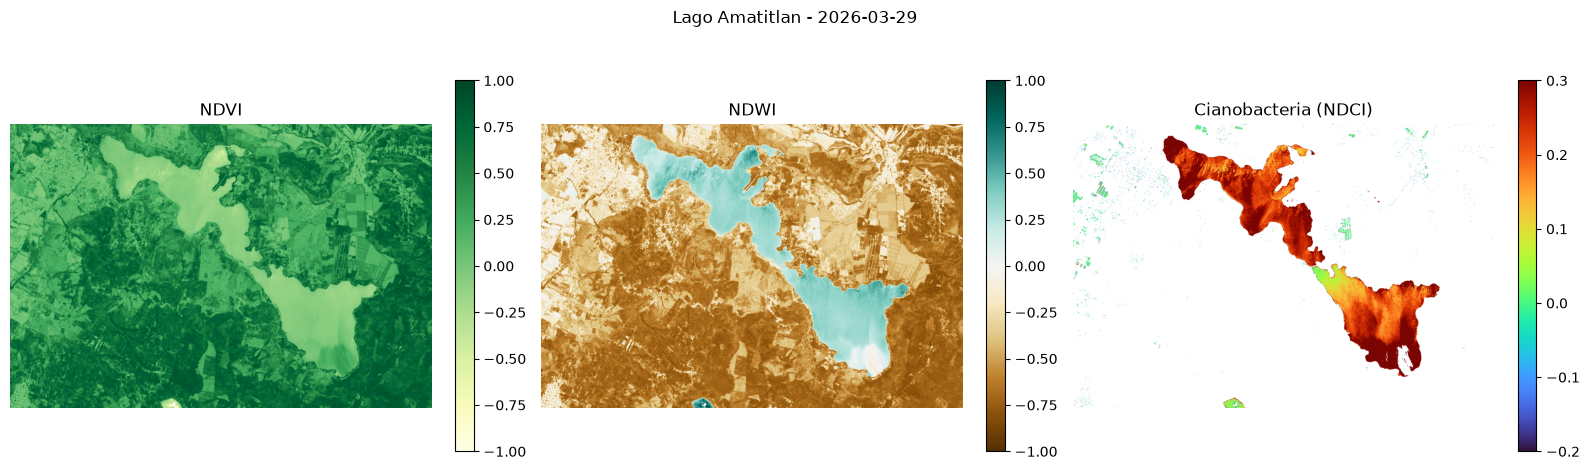

In [ ]:
def mapas(lago, fecha):
    ix = indices(lago, fecha)
    cyano = np.where(ix["agua"], ix["ndci"], np.nan) 

    fig, ejes = plt.subplots(1, 3, figsize=(16, 5))
    for eje, (dato, titulo, cmap, lim) in zip(ejes, [
        (ix["ndvi"], "NDVI", "YlGn", (-1, 1)),
        (ix["ndwi"], "NDWI", "BrBG", (-1, 1)),
        (cyano, "Cianobacteria (NDCI)", "turbo", (-0.2, 0.3)),
    ]):
        im = eje.imshow(dato, cmap=cmap, vmin=lim[0], vmax=lim[1])
        eje.set_title(titulo)
        eje.axis("off")
        fig.colorbar(im, ax=eje, fraction=0.04)

    fig.suptitle(f"Lago {lago} - {fecha}")
    plt.tight_layout()
    plt.show()


mapas("Atitlan", "2026-04-13")
mapas("Amatitlan", "2026-03-29")

Promedio de cada índice por lago y por fecha (el índice de cianobacteria solo sobre píxeles de agua

In [ ]:
filas = []
for lago, info in lagos.items():
    for fecha in info["fechas"]:
        ix = indices(lago, fecha)
        agua = ix["agua"]
        filas.append({
            "lago": lago,
            "fecha": pd.Timestamp(fecha),
            "cyano_ndci": np.nanmean(ix["ndci"][agua]),
            "chla_ug_l": np.nanmedian(ix["chla"][agua]),
            "ndvi": np.nanmean(ix["ndvi"]),
            "ndwi": np.nanmean(ix["ndwi"]),
            "pct_agua": 100 * agua.mean(),
        })

df = pd.DataFrame(filas)
df

,lago,fecha,cyano_ndci,chla_ug_l,ndvi,ndwi,pct_agua
0,Atitlan,2025-01-18,-0.139480,0.000000,0.702571,-0.437362,17.188273
1,Atitlan,2025-04-13,-0.030092,3.392740,0.466625,-0.368073,25.402354
2,Atitlan,2025-05-13,-0.009468,4.022008,0.374575,-0.266705,28.926897
3,Atitlan,2025-07-17,0.013983,4.316447,0.570903,-0.416335,24.870788
4,Atitlan,2025-11-21,-0.018377,4.071000,0.567796,-0.368156,21.791410
5,Atitlan,2025-12-29,-0.058649,3.058368,0.516656,-0.336500,27.184611
6,Atitlan,2026-02-12,-0.024182,3.678900,0.538903,-0.401842,20.022484
7,Atitlan,2026-03-24,-0.010235,3.886231,0.409688,-0.307974,25.999910
8,Atitlan,2026-04-13,0.006495,4.254744,0.496444,-0.410338,25.278715
9,Atitlan,2026-04-28,-0.019616,3.733925,0.422790,-0.330838,27.862689


Evolución temporal del índice de cianobacteria

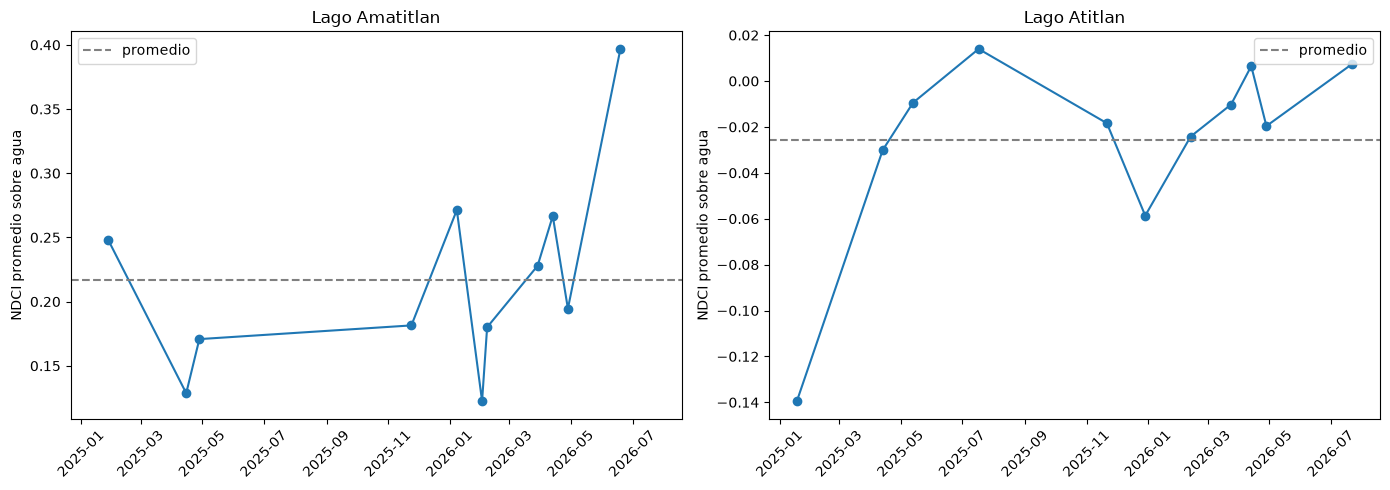

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for eje, (lago, g) in zip(ejes, df.groupby("lago")):
    eje.plot(g["fecha"], g["cyano_ndci"], marker="o")
    eje.axhline(g["cyano_ndci"].mean(), color="gray", ls="--", label="promedio")
    eje.set_title(f"Lago {lago}")
    eje.set_ylabel("NDCI promedio sobre agua")
    eje.tick_params(axis="x", rotation=45)
    eje.legend()

plt.tight_layout()
plt.show()

In [ ]:
for lago, g in df.groupby("lago"):
    umbral = g["cyano_ndci"].mean() + g["cyano_ndci"].std()
    picos = g[g["cyano_ndci"] >= umbral]
    maximo = g.loc[g["cyano_ndci"].idxmax()]

    print(f"Lago {lago}")
    print(f"  rango NDCI: {g['cyano_ndci'].min():.3f} a {g['cyano_ndci'].max():.3f}")
    print(f"  umbral de pico: {umbral:.3f}")
    print(f"  maximo: {maximo['fecha'].date()} (NDCI {maximo['cyano_ndci']:.3f}, "
          f"chl-a {maximo['chla_ug_l']:.1f} ug/L)")
    print(f"  fechas criticas: {[str(f.date()) for f in picos['fecha']]}")
    print(f"  tres fechas mas altas: {[str(f.date()) for f in g.nlargest(3, 'cyano_ndci')['fecha']]}\n")

Lago Amatitlan
  rango NDCI: 0.122 a 0.397
  umbral de pico: 0.295
  maximo: 2026-06-19 (NDCI 0.397, chl-a 54.2 ug/L)
  fechas criticas: ['2026-06-19']
  tres fechas mas altas: ['2026-06-19', '2026-01-08', '2026-04-13']

Lago Atitlan
  rango NDCI: -0.139 a 0.014
  umbral de pico: 0.017
  maximo: 2025-07-17 (NDCI 0.014, chl-a 4.3 ug/L)
  fechas criticas: []
  tres fechas mas altas: ['2025-07-17', '2026-07-22', '2026-04-13']



Mapas del índice de cianobacteria en las fechas de mayor y menor floración de cada lago

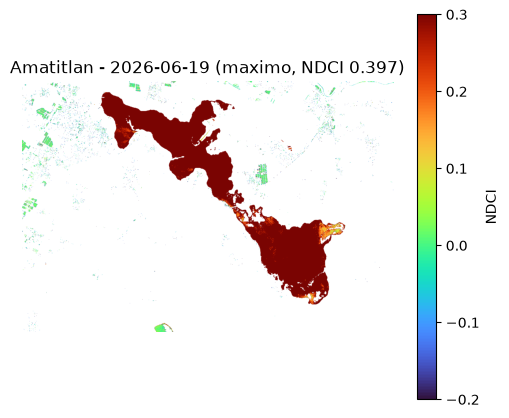

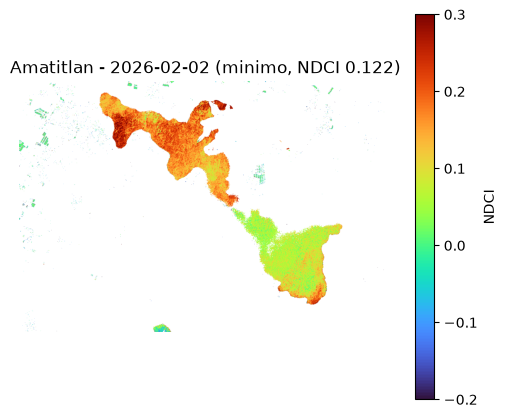

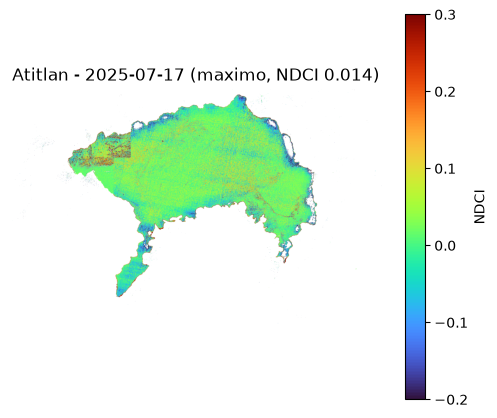

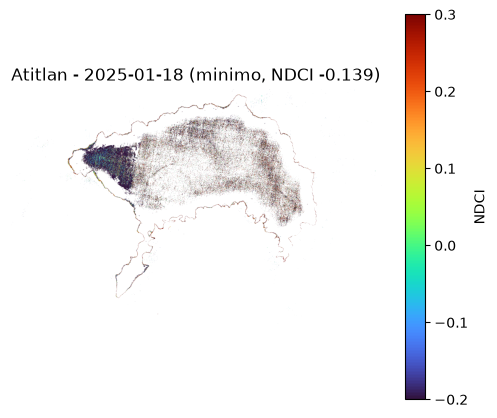

In [ ]:
for lago, g in df.groupby("lago"):
    for etiqueta, fila in [("maximo", g.loc[g["cyano_ndci"].idxmax()]),
                           ("minimo", g.loc[g["cyano_ndci"].idxmin()])]:
        fecha = fila["fecha"].strftime("%Y-%m-%d")
        ix = indices(lago, fecha)
        plt.figure(figsize=(6, 5))
        plt.imshow(np.where(ix["agua"], ix["ndci"], np.nan), cmap="turbo", vmin=-0.2, vmax=0.3)
        plt.title(f"{lago} - {fecha} ({etiqueta}, NDCI {fila['cyano_ndci']:.3f})")
        plt.colorbar(label="NDCI")
        plt.axis("off")
        plt.show()

## Interpretación

- Amatitlán se mantiene en niveles altos durante todo el periodo: el NDCI promedio sobre agua oscila entre 0.12 y 0.40, equivalente a una clorofila-a de 5 a 54 ug/L. La serie fluctúa más de lo que sube o baja, con mínimos relativos en abril de 2025 y febrero de 2026, cerca de 0.12, y máximos en enero y abril de 2026, de 0.27, y sobre todo en junio de 2026, con 0.40 y unos 54 ug/L. Esa última es la única fecha que supera el umbral de promedio más una desviación estándar y por lo tanto la fecha crítica del periodo. Aun así, el promedio de 2026, de 0.24, supera al de 2025, de 0.18, lo que sugiere un leve empeoramiento.

- Atitlán se mantiene estable y limpio: su NDCI promedio oscila alrededor de cero, entre menos 0.06 y 0.014, con clorofila-a de 3 a 4 ug/L, y ninguna fecha supera el umbral de pico. En las 11 imágenes no se detecta una floración comparable a las de Amatitlán. Los valores más altos, caen en julio de 2025, abril de 2026 y julio de 2026.

- La diferencia se explica por las condiciones propias de cada lago: Amatitlán es caliente, pequeño y recibe el río Villalobos con las aguas residuales y la escorrentía del área metropolitana. Atitlán es mucho más profundo y voluminoso, con menor carga de nutrientes por volumen, así que diluye mejor los aportes y solo mostraría floraciones en eventos puntuales.

- El análisis tiene tres limitaciones: la imagen de Atitlán del 18 de enero de 2025 queda con solo 17 por ciento de píxeles de agua válidos por las sombras de las paredes del cráter con sol bajo, de modo que su NDCI de menos 0.14 no es comparable con el resto, el NDCI es un proxy de clorofila-a y no una medición directa de cianobacterias, sin validación con muestreo en campo, y el NDVI y el NDWI se calculan sobre toda la escena, por lo que reflejan más el entorno que el lago. La fracción de agua se mantiene estable en ambos casos, cerca de 25% en Atitlán y 12 por ciento en Amatitlán, sin cambios apreciables en la superficie de los cuerpos de agua.

## Análisis espacial


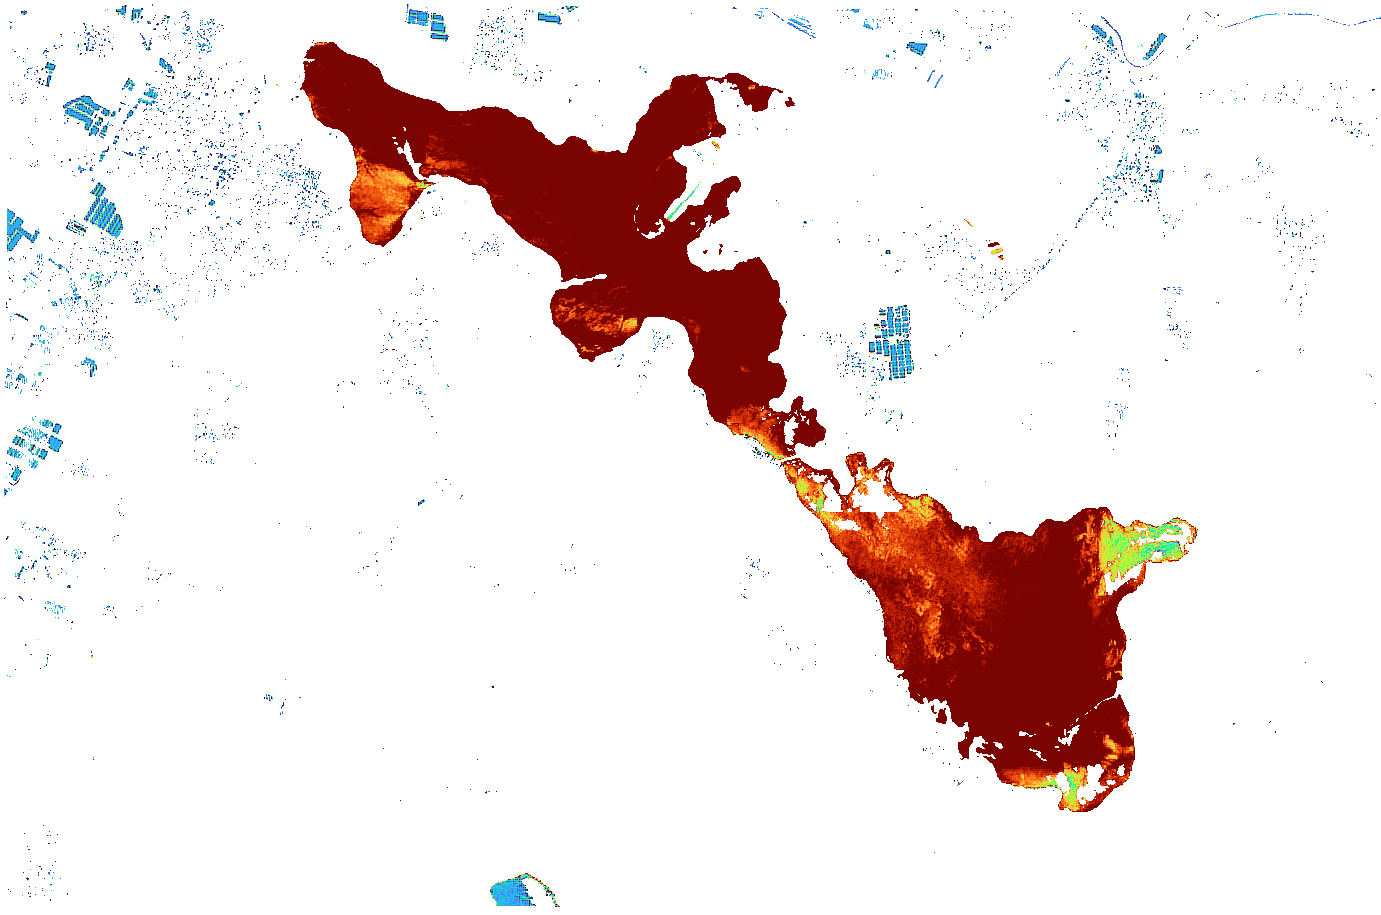

In [ ]:
import warnings

import folium
from rasterio.warp import calculate_default_transform, reproject

warnings.filterwarnings("ignore", message="Mean of empty slice")


def a_latlon(lago, fecha, arr):
    with rasterio.open(f"{DATA_DIR}/{lago}_{fecha}.tif") as src:
        transformacion, ancho, alto = calculate_default_transform(
            src.crs, "EPSG:4326", src.width, src.height, *src.bounds)
        destino = np.full((alto, ancho), np.nan, dtype="float32")
        reproject(arr, destino, src_transform=src.transform, src_crs=src.crs,
                  dst_transform=transformacion, dst_crs="EPSG:4326", dst_nodata=np.nan)

    oeste, sur, este, norte = rasterio.transform.array_bounds(alto, ancho, transformacion)
    return destino, [[sur, oeste], [norte, este]]


def mapa_interactivo(lago, fecha):
    ix = indices(lago, fecha)
    datos, limites = a_latlon(lago, fecha, np.where(ix["agua"], ix["ndci"], np.nan))

    color = plt.cm.turbo(plt.Normalize(-0.1, 0.4)(datos))
    color[..., 3] = np.where(np.isnan(datos), 0, 0.75)

    bbox = lagos[lago]["bbox"]
    mapa = folium.Map(zoom_start=12, location=[(bbox["south"] + bbox["north"]) / 2,
                                               (bbox["west"] + bbox["east"]) / 2])
    folium.raster_layers.ImageOverlay(color, bounds=limites).add_to(mapa)
    return mapa


mapa_interactivo("Amatitlan", "2026-06-19")


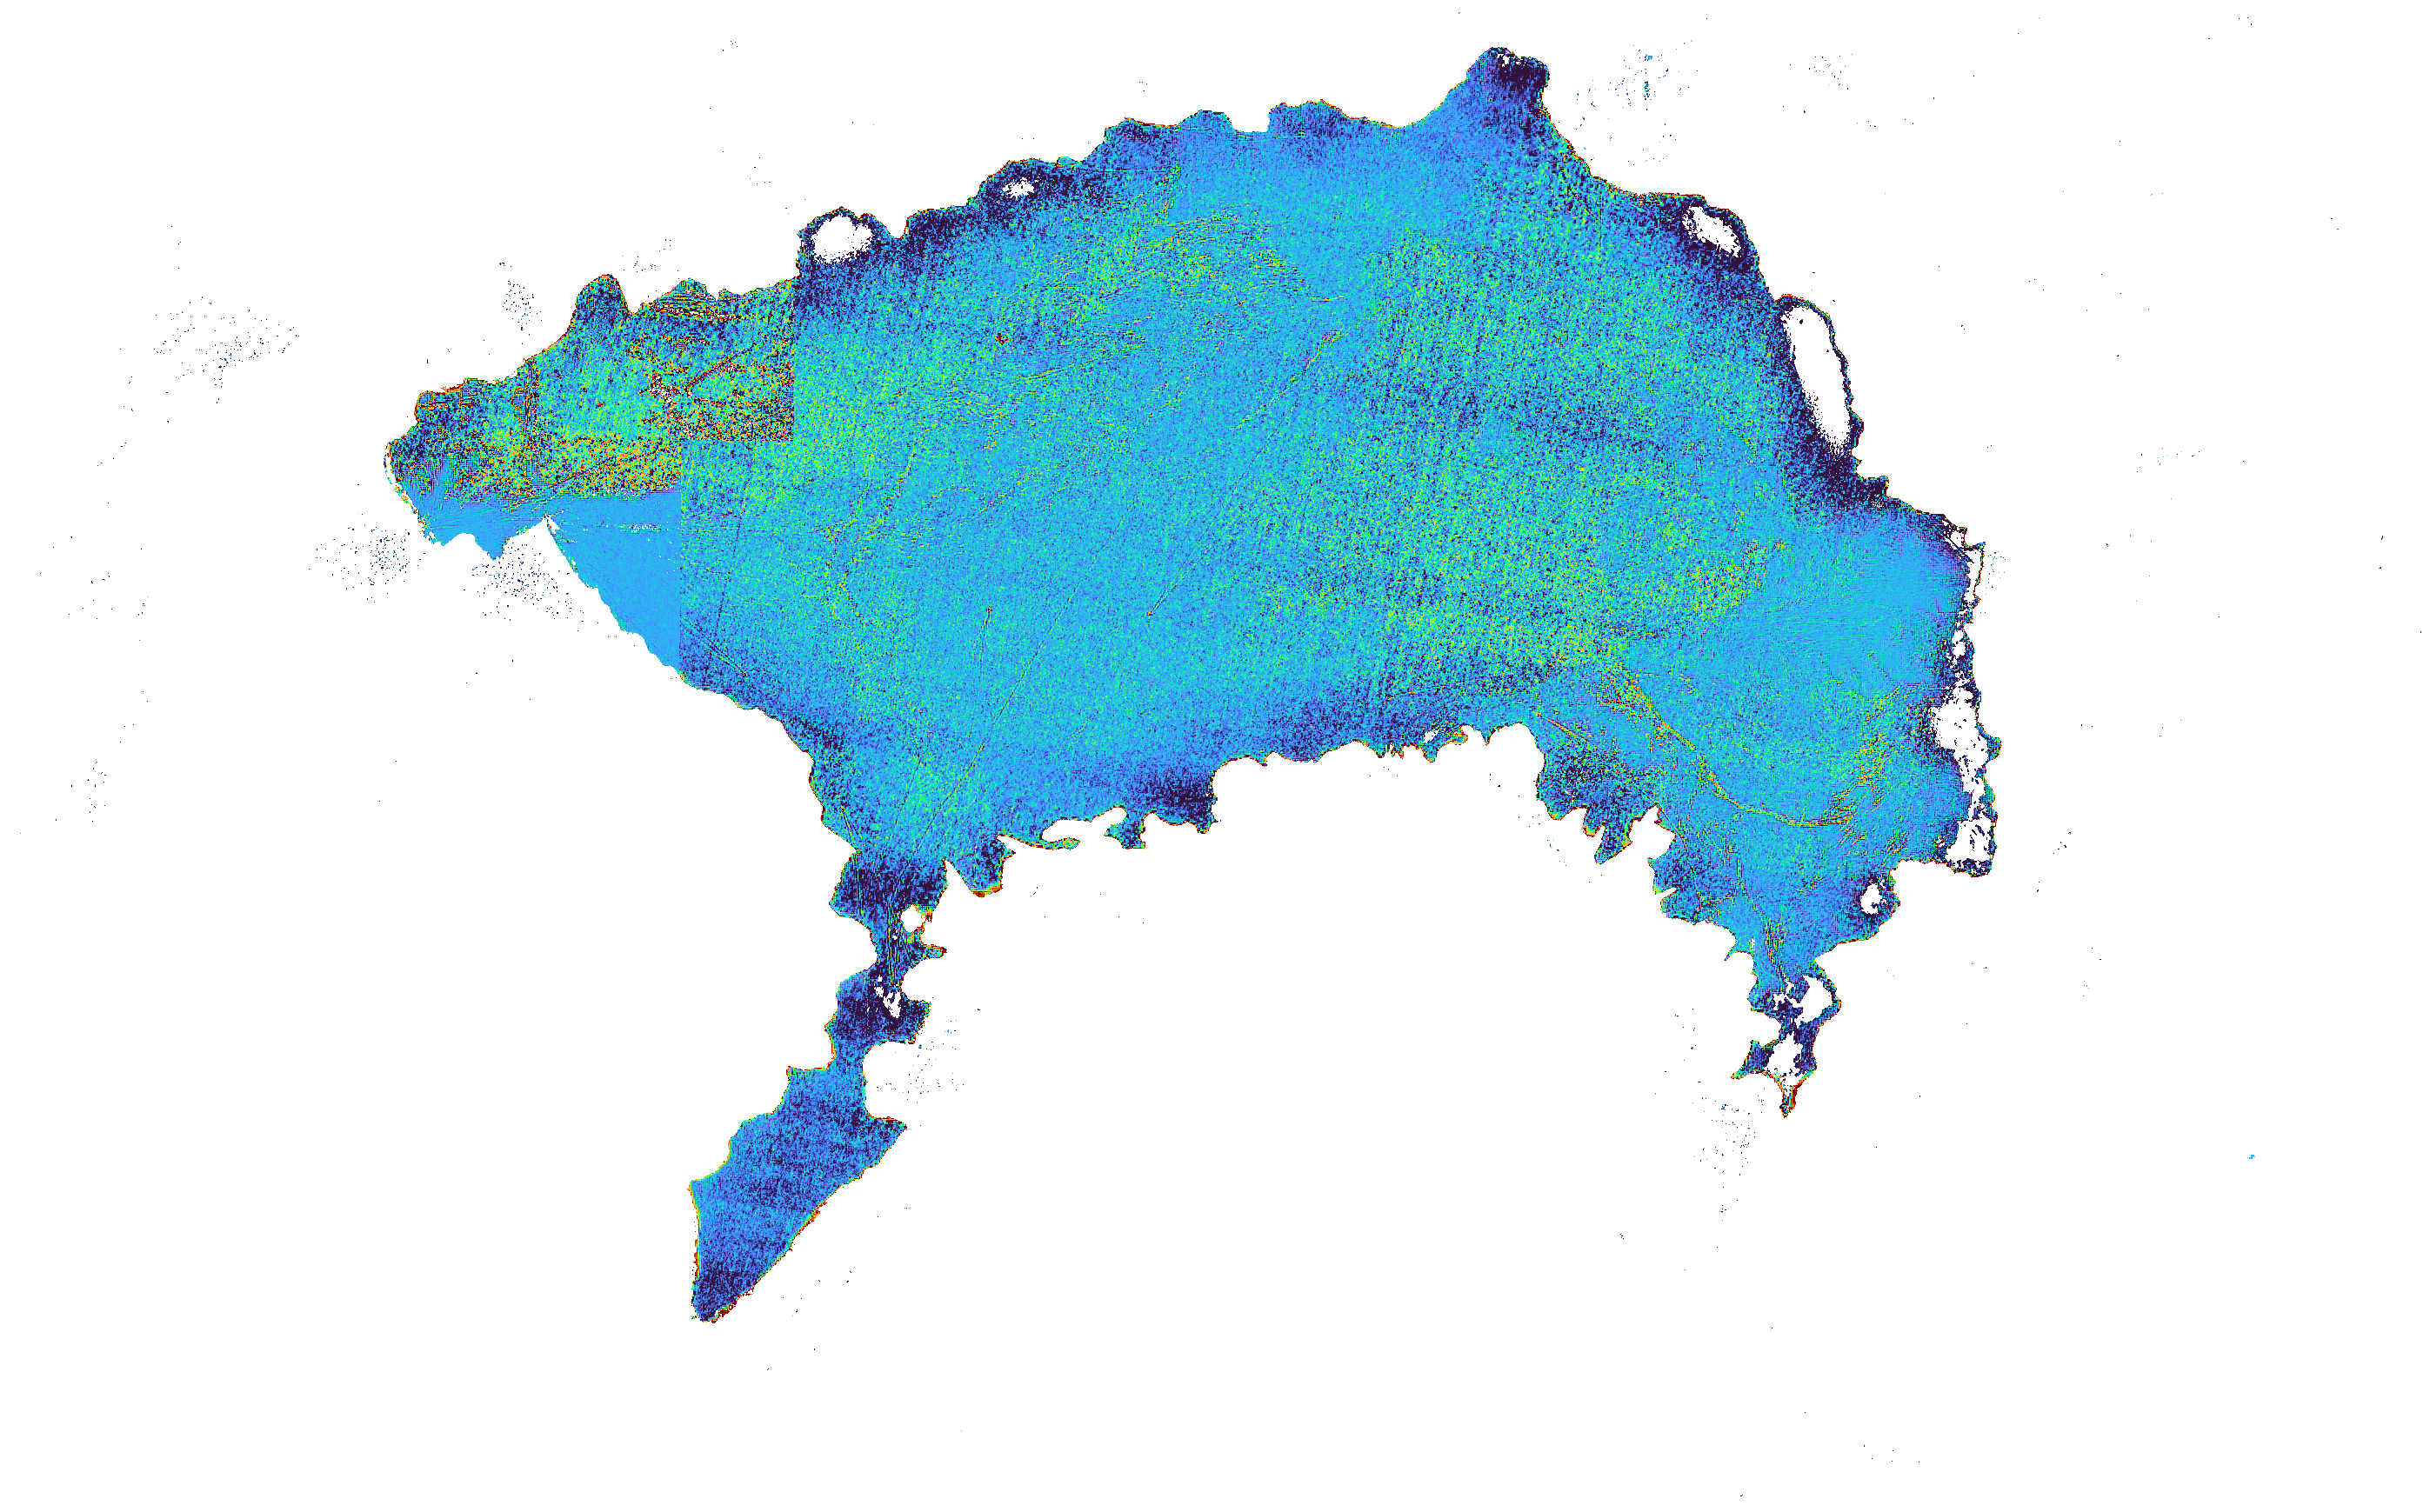

In [ ]:
mapa_interactivo("Atitlan", "2025-07-17")

Mapas comparativos de todas las fechas de cada lago, con la misma escala de color

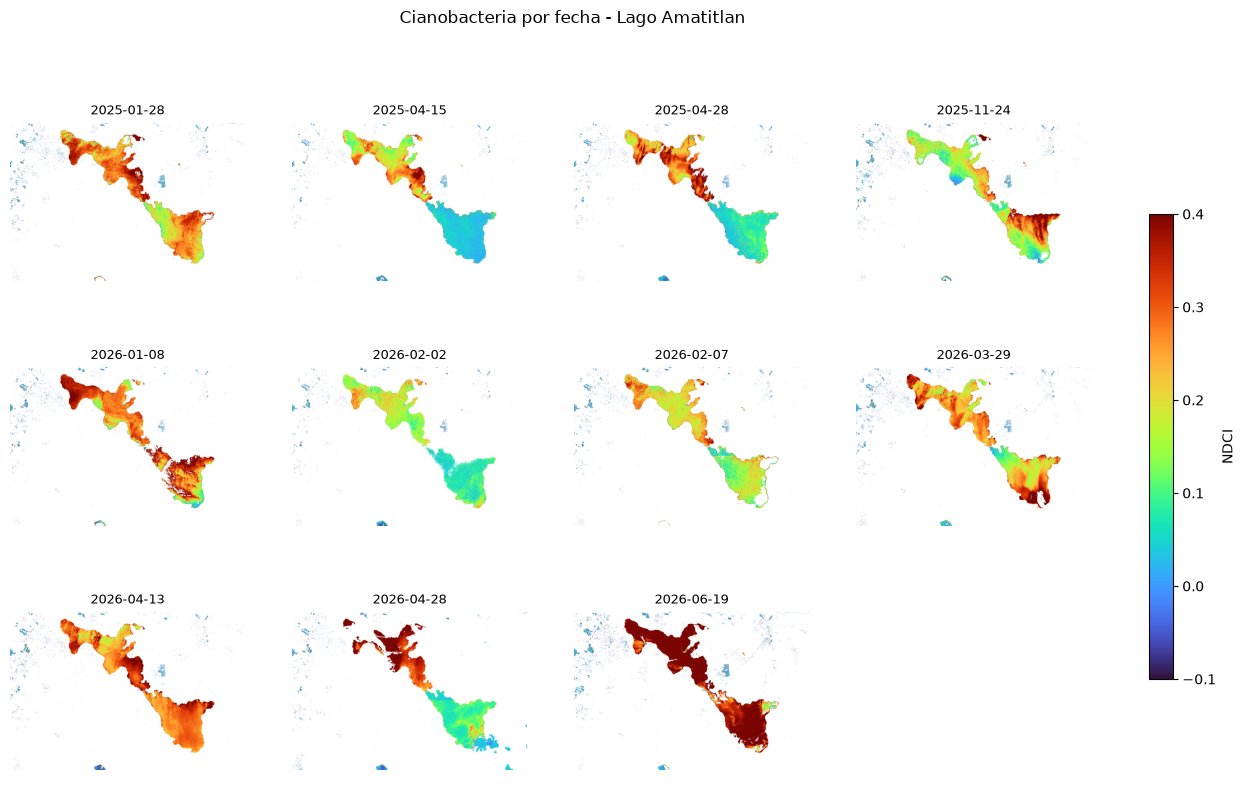

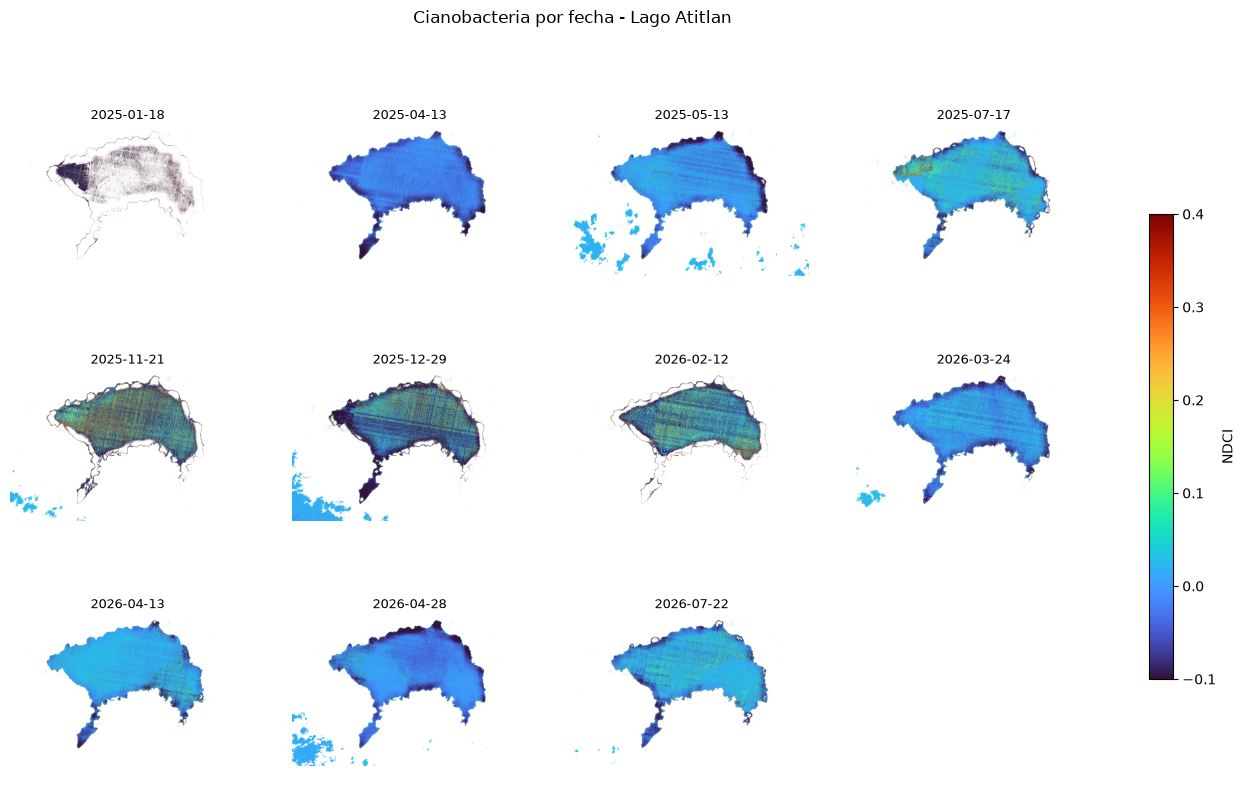

In [ ]:
def rejilla(lago):
    fechas = lagos[lago]["fechas"]
    fig, ejes = plt.subplots(3, 4, figsize=(15, 9))
    for eje, fecha in zip(ejes.ravel(), fechas):
        ix = indices(lago, fecha)
        im = eje.imshow(np.where(ix["agua"], ix["ndci"], np.nan), cmap="turbo", vmin=-0.1, vmax=0.4)
        eje.set_title(fecha, fontsize=9)
    for eje in ejes.ravel():
        eje.axis("off")

    fig.colorbar(im, ax=ejes, fraction=0.02, label="NDCI")
    fig.suptitle(f"Cianobacteria por fecha - Lago {lago}")
    plt.show()


rejilla("Amatitlan")
rejilla("Atitlan")

Para ver dónde se concentran los valores altos se apilan las 11 fechas de cada lago, que comparten la
misma malla, y se promedia el índice píxel a píxel

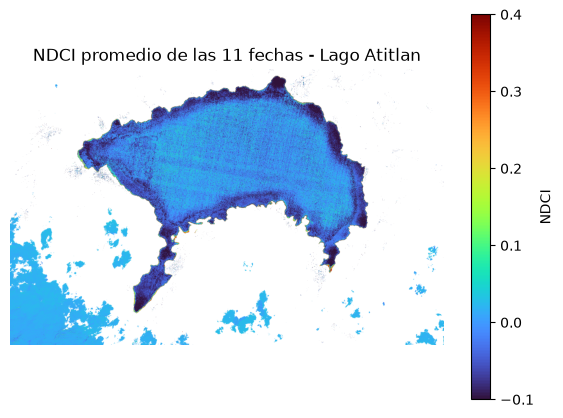

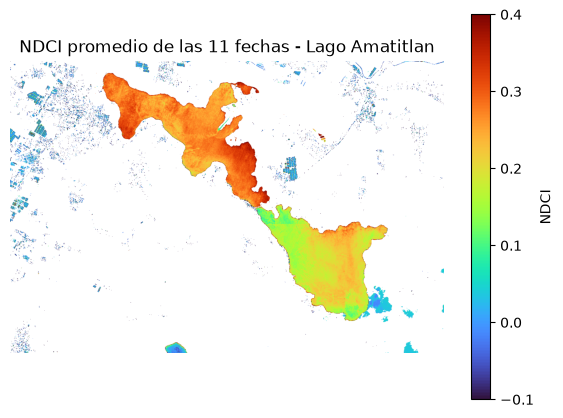

In [ ]:
UMBRAL_ALTO = 0.2  


def apilar(lago):
    capas = []
    for fecha in lagos[lago]["fechas"]:
        ix = indices(lago, fecha)
        capas.append(np.where(ix["agua"], ix["ndci"], np.nan))
    return np.array(capas)


pilas = {lago: apilar(lago) for lago in lagos}

for lago, pila in pilas.items():
    plt.figure(figsize=(7, 5))
    plt.imshow(np.nanmean(pila, axis=0), cmap="turbo", vmin=-0.1, vmax=0.4)
    plt.title(f"NDCI promedio de las 11 fechas - Lago {lago}")
    plt.colorbar(label="NDCI")
    plt.axis("off")
    plt.show()

Se compara el NDCI promedio entre las mitades norte y sur del agua permanente, definida como los
píxeles que son agua en al menos 9 de las 11 fechas

In [ ]:
from rasterio.warp import transform as a_geograficas


def gradiente(lago):
    pila = pilas[lago]
    cuerpo = np.sum(~np.isnan(pila), axis=0) >= 9
    promedio = np.nanmean(pila, axis=0)

    with rasterio.open(f"{DATA_DIR}/{lago}_{lagos[lago]['fechas'][0]}.tif") as src:
        fila, columna = np.where(cuerpo)
        x, y = rasterio.transform.xy(src.transform, fila, columna)
        lon, lat = a_geograficas(src.crs, "EPSG:4326", x, y)

    lat = np.array(lat)
    valores = promedio[cuerpo]
    mitad = (lat.min() + lat.max()) / 2
    altos = valores >= np.nanquantile(valores, 0.9)

    print(f"Lago {lago}: {cuerpo.sum() * 100 / 1e6:.1f} km2 de agua permanente, "
          f"NDCI promedio {np.nanmean(valores):.3f}")
    print(f"  mitad norte {np.nanmean(valores[lat >= mitad]):.3f}, "
          f"mitad sur {np.nanmean(valores[lat < mitad]):.3f}")
    print(f"  el 10% de píxeles más altos promedia {np.nanmean(valores[altos]):.3f} "
          f"y se centra en {lat[altos].mean():.4f} N\n")


for lago in lagos:
    gradiente(lago)

Lago Atitlan: 102.1 km2 de agua permanente, NDCI promedio -0.013
  mitad norte -0.012, mitad sur -0.017
  el 10% de píxeles más altos promedia 0.079 y se centra en 14.6989 N

Lago Amatitlan: 14.3 km2 de agua permanente, NDCI promedio 0.230
  mitad norte 0.264, mitad sur 0.192
  el 10% de píxeles más altos promedia 0.323 y se centra en 14.4704 N



## Interpretación espacial

- Amatitlán concentra la floración en la mitad norte: sobre los 14.3 km2 de agua permanente el NDCI promedio de las 11 fechas es 0.230, pero la mitad norte llega a 0.264 y la sur baja a 0.192, y el 10 % de píxeles más altos promedia 0.323 y se centra en la cuenca norponiente, justo donde el río Villalobos entrega el agua que baja del área metropolitana. 

- La zona de acumulación es estable y no un episodio suelto: los píxeles del norte superan el umbral en cerca del 71% de las fechas frente al 44% del sur, y el patrón se repite en las 11 imágenes

- Entre fechas cambia la intensidad, no la ubicación: el mapa de diferencia entre junio de 2026 y febrero de 2026 es positivo en toda la superficie, con aumentos de hasta 0.4, así que el lago entero sube y baja.

- Atitlán no muestra ninguna estructura espacial: el promedio de las 11 fechas es plano alrededor de cero, con menos 0.012 en la mitad norte y menos 0.017 en la sur, y los decilos más alto y más bajo se centran prácticamente en el mismo punto, lo que indica ruido y no un patrón. Los únicos píxeles que superan el umbral forman una franja delgada en la orilla, donde el píxel de 10 metros mezcla agua con vegetación ribereña. No hay zonas persistentes de acumulación.

## Correlación de NDVI y NDWI con la cianobacteria

In [ ]:
# la imagen de Atitlán del 2025-01-18 es anómala, así que se repite el cálculo sin ella
sin_anomala = df.drop(df[(df["lago"] == "Atitlan") & (df["fecha"] == "2025-01-18")].index)

print("Correlación entre fechas (promedios por imagen)")
for etiqueta, tabla in [("todas las fechas", df), ("sin 2025-01-18", sin_anomala)]:
    print(f"  {etiqueta}")
    for lago, g in tabla.groupby("lago"):
        r = g[["cyano_ndci", "ndvi", "ndwi"]].corr()["cyano_ndci"]
        print(f"    {lago}: NDVI {r['ndvi']:+.2f}   NDWI {r['ndwi']:+.2f}")

Correlación entre fechas (promedios por imagen)
  todas las fechas
    Amatitlan: NDVI +0.51   NDWI -0.21
    Atitlan: NDVI -0.61   NDWI +0.29
  sin 2025-01-18
    Amatitlan: NDVI +0.51   NDWI -0.21
    Atitlan: NDVI +0.06   NDWI -0.31


In [ ]:
def corr_pixeles(lago, fecha):
    ix = indices(lago, fecha)
    m = ix["agua"] & ~np.isnan(ix["ndci"])
    return (np.corrcoef(ix["ndci"][m], ix["ndvi"][m])[0, 1],
            np.corrcoef(ix["ndci"][m], ix["ndwi"][m])[0, 1])


corr = pd.DataFrame(
    [{"lago": lago, "fecha": fecha, "r_ndvi": r[0], "r_ndwi": r[1]}
     for lago, info in lagos.items() for fecha in info["fechas"]
     for r in [corr_pixeles(lago, fecha)]]
)
print(corr.groupby("lago")[["r_ndvi", "r_ndwi"]].mean(), "\n")
corr

             r_ndvi    r_ndwi
lago                         
Amatitlan  0.338602  0.014729
Atitlan    0.558564 -0.347297 



,lago,fecha,r_ndvi,r_ndwi
0,Atitlan,2025-01-18,0.544587,-0.160843
1,Atitlan,2025-04-13,0.557981,-0.495511
2,Atitlan,2025-05-13,0.674136,-0.483670
3,Atitlan,2025-07-17,0.508171,-0.225574
4,Atitlan,2025-11-21,0.521375,-0.162342
5,Atitlan,2025-12-29,0.562191,-0.365213
6,Atitlan,2026-02-12,0.539905,-0.310800
7,Atitlan,2026-03-24,0.536491,-0.419711
8,Atitlan,2026-04-13,0.516853,-0.378072
9,Atitlan,2026-04-28,0.660301,-0.526349


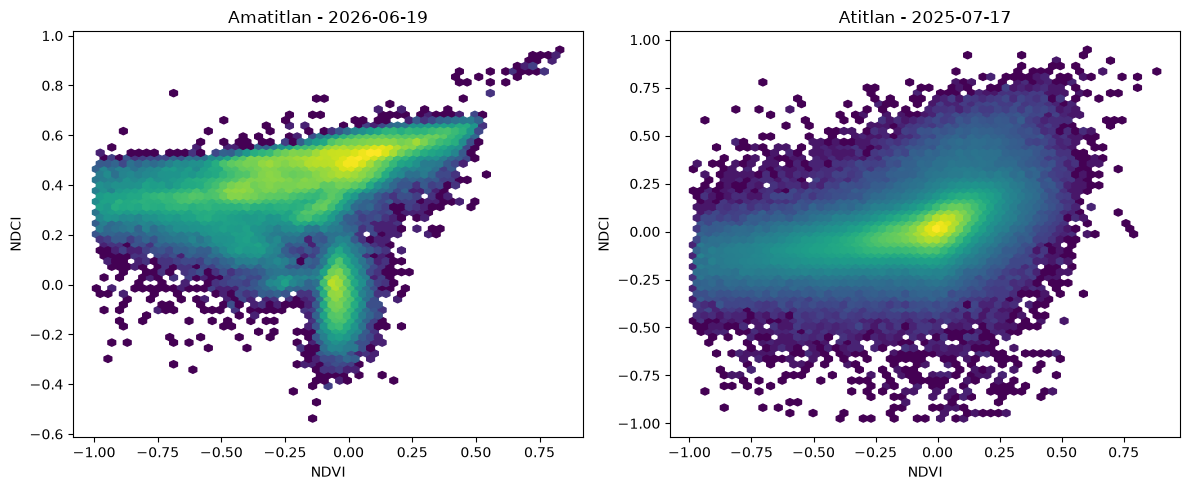

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 5))
for eje, (lago, fecha) in zip(ejes, [("Amatitlan", "2026-06-19"), ("Atitlan", "2025-07-17")]):
    ix = indices(lago, fecha)
    m = ix["agua"] & ~np.isnan(ix["ndci"])
    eje.hexbin(ix["ndvi"][m], ix["ndci"][m], gridsize=60, cmap="viridis", bins="log")
    eje.set_title(f"{lago} - {fecha}")
    eje.set_xlabel("NDVI")
    eje.set_ylabel("NDCI")

plt.tight_layout()
plt.show()

## Interpretación de las correlaciones

- La relación con el NDVI es positiva y es la más informativa: dentro de cada imagen los píxeles de agua con más cianobacteria también tienen NDVI más alto, con una correlación media de 0.56 en Atitlán y 0.34 en Amatitlán. Tiene sentido físico, porque la cianobacteria es material fotosintético en suspensión y levanta la reflectancia en el borde rojo y el infrarrojo cercano, que es justo lo que mide el NDVI.

- Entre fechas, en Amatitlán la correlación con el NDVI es 0.51: las fechas con la cuenca más verde son también las de mayor floración, algo coherente con la lluvia, que reverdece el entorno y al mismo tiempo arrastra nutrientes.

- Con el NDWI la relación es la inversa pero más débil: negativa en Atitlán, con una correlación media de menos 0.35 por píxel, porque el agua cargada pierde la firma espectral de agua limpia. En Amatitlán ronda cero, 0.02, y cambia de signo entre fecha.

- La correlación entre fechas de Atitlán con el NDVI aparece en menos 0.60, pero es un artefacto: al quitar la imagen anómala del 2025/01/18 cae a 0.06, es decir, no hay relación. Con solo 11 fechas una imagen mala domina el resultado, y por eso conviene mirar la correlación por píxel, que es estable en las 11 imágenes.

- Ambientalmente, en Amatitlán el NDVI del agua sirve como señal de apoyo a la floración, mientras que en Atitlán las correlaciones reflejan sobre todo la mezcla de píxeles en la orilla y no un proceso en el cuerpo del lago.

## Comparación entre los dos lagos

In [ ]:
resumen = df.groupby("lago").agg(
    ndci_medio=("cyano_ndci", "mean"),
    ndci_min=("cyano_ndci", "min"),
    ndci_max=("cyano_ndci", "max"),
    chla_media=("chla_ug_l", "mean"),
    chla_max=("chla_ug_l", "max"),
)
resumen["fechas_sobre_umbral"] = df[df["cyano_ndci"] > UMBRAL_ALTO].groupby("lago").size()
resumen = resumen.fillna(0)
resumen

,ndci_medio,ndci_min,ndci_max,chla_media,chla_max,fechas_sobre_umbral
lago,,,,,,
Amatitlan,0.217116,0.122462,0.396820,12.493453,54.158844,5.0
Atitlan,-0.025652,-0.139480,0.013983,3.513730,4.316447,0.0


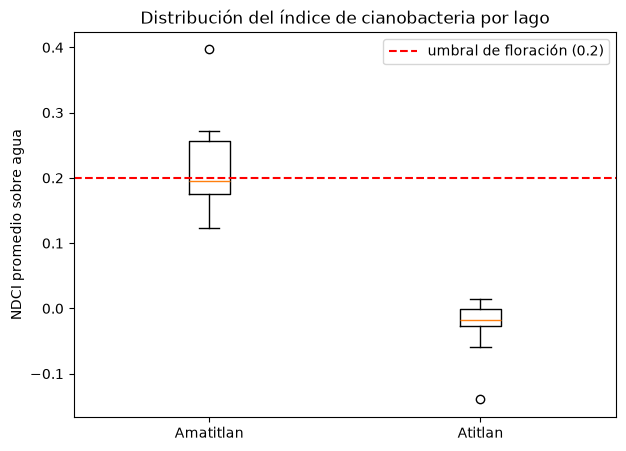

In [ ]:
plt.figure(figsize=(7, 5))
plt.boxplot([g["cyano_ndci"] for _, g in df.groupby("lago")],
            tick_labels=[lago for lago, _ in df.groupby("lago")])
plt.axhline(UMBRAL_ALTO, color="red", ls="--", label=f"umbral de floración ({UMBRAL_ALTO})")
plt.ylabel("NDCI promedio sobre agua")
plt.title("Distribución del índice de cianobacteria por lago")
plt.legend()
plt.show()

## Comparación de la proliferación en ambos lagos

- La intensidad no es comparable entre los dos lagos: Amatitlán promedia un NDCI de 0.217 con un máximo de 0.397, equivalente a una clorofila-a media de 12.5 ug/L y máxima de 54.2 ug/L, mientras que Atitlán promedia menos 0.026 con un máximo de 0.014 y una clorofila a de 3.5 ug/L en promedio y 4.3ug/L como máximo. Es una diferencia de un orden de magnitud en clorofila a.

- La frecuencia también los separa: 5 de las 11 fechas de Amatitlán superan el umbral de 0.2 y ninguna de Atitlán lo hace, y el boxplot muestra que las dos distribuciones no se traslapan. En el espacio pasa lo mismo, ya que en Amatitlán el 55 por ciento de la superficie supera el umbral en promedio frente al 5% de Atitlán, y ese 5% corresponde a la orilla y a las fechas con bruma. En Amatitlán la floración es un estado permanente que sube y baja de intensidad, no un evento aislado.

- Las causas apuntan a la presión urbana y a la morfología: Amatitlán tiene unos 15 km2 y poca profundidad, y recibe por el río Villalobos el drenaje de la cuenca metropolitana, con aguas residuales en su mayoría sin tratar, descargas industriales y escorrentía de suelo urbanizado y agrícola, todo entrando por la orilla norte, que es precisamente la de mayor NDCI. Está a menor altitud y con agua más cálida, lo que favorece el crecimiento.

- Atitlán tiene unos 130 km2 y una profundidad de varios cientos de metros, está a mayor altitud y con agua más fría, y su cuenca es menos poblada y con más cobertura de bosque y café, de modo que el mismo aporte de nutrientes se diluye en un volumen mucho mayor. La combinación de carga alta de nutrientes con volumen pequeño explica que un lago esté florecido todo el año y el otro no.

## Análisis exploratorio adicional

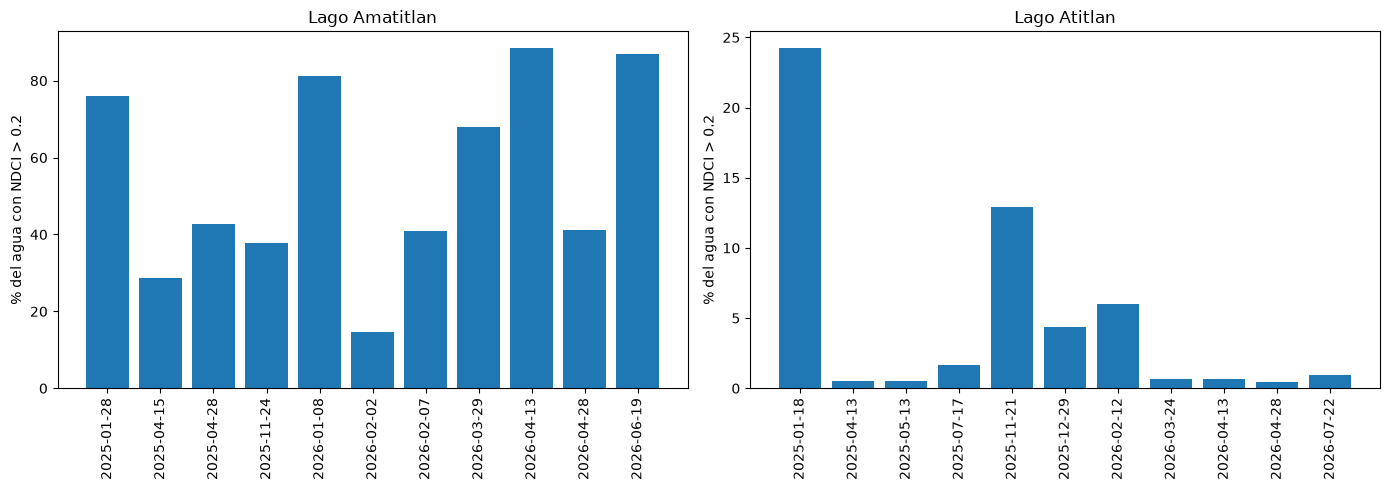

,lago,fecha,pct_floracion
0,Atitlan,2025-01-18,24.220740
1,Atitlan,2025-04-13,0.552972
2,Atitlan,2025-05-13,0.533560
3,Atitlan,2025-07-17,1.669092
4,Atitlan,2025-11-21,12.904908
5,Atitlan,2025-12-29,4.382539
6,Atitlan,2026-02-12,5.983768
7,Atitlan,2026-03-24,0.652127
8,Atitlan,2026-04-13,0.673106
9,Atitlan,2026-04-28,0.482228


In [ ]:
ext = pd.DataFrame([
    {"lago": lago, "fecha": pd.Timestamp(fecha),
     "pct_floracion": 100 * np.nansum(capa > UMBRAL_ALTO) / np.sum(~np.isnan(capa))}
    for lago, pila in pilas.items()
    for fecha, capa in zip(lagos[lago]["fechas"], pila)
])

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
for eje, (lago, g) in zip(ejes, ext.groupby("lago")):
    eje.bar(g["fecha"].dt.strftime("%Y-%m-%d"), g["pct_floracion"])
    eje.set_title(f"Lago {lago}")
    eje.set_ylabel("% del agua con NDCI > 0.2")
    eje.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()
ext

Zonas persistentes: porcentaje de fechas en que cada píxel superó el umbral

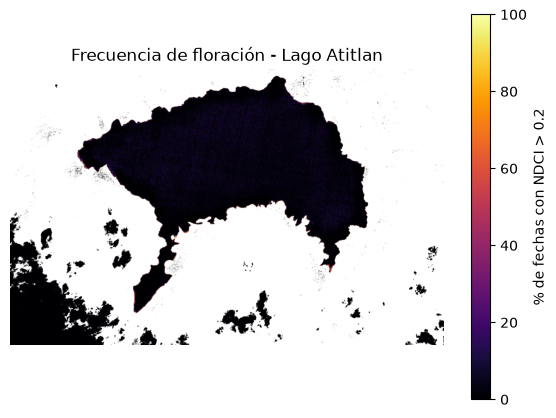

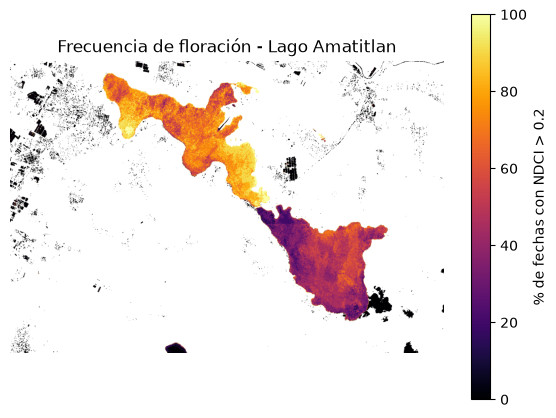

In [ ]:
for lago, pila in pilas.items():
    validos = np.sum(~np.isnan(pila), axis=0)
    frecuencia = np.where(validos > 0,
                          100 * np.sum(pila > UMBRAL_ALTO, axis=0) / np.maximum(validos, 1), np.nan)

    plt.figure(figsize=(7, 5))
    plt.imshow(frecuencia, cmap="inferno", vmin=0, vmax=100)
    plt.title(f"Frecuencia de floración - Lago {lago}")
    plt.colorbar(label="% de fechas con NDCI > 0.2")
    plt.axis("off")
    plt.show()

Distribución de los valores dentro de cada fecha y mapa de diferencia entre la fecha máxima y la mínima

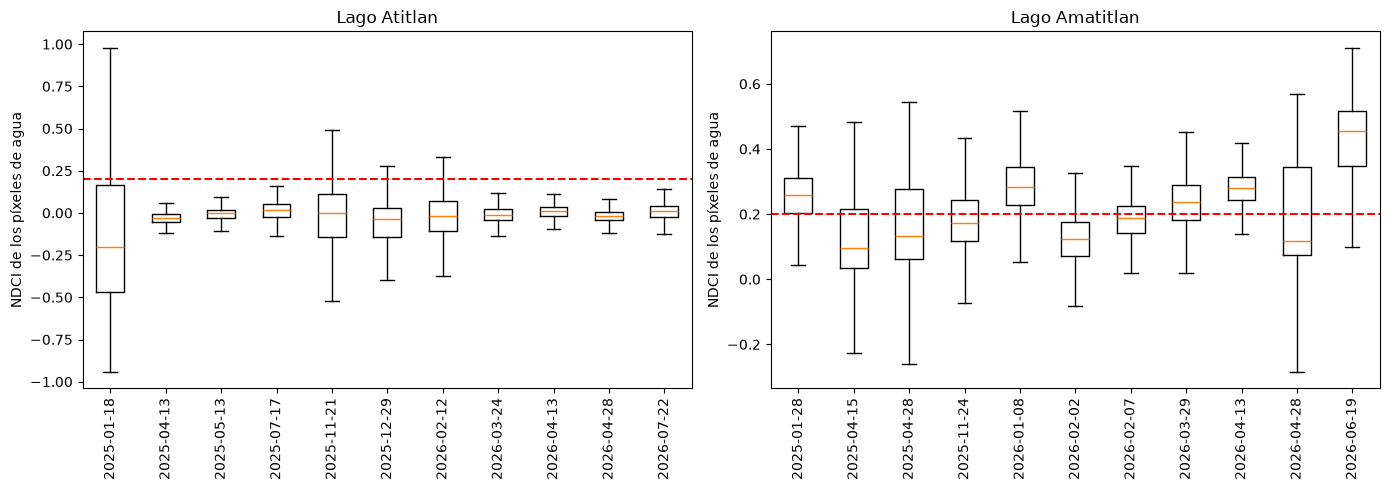

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
for eje, (lago, pila) in zip(ejes, pilas.items()):
    datos = [capa[~np.isnan(capa)][::20] for capa in pila]
    eje.boxplot(datos, tick_labels=lagos[lago]["fechas"], showfliers=False)
    eje.axhline(UMBRAL_ALTO, color="red", ls="--")
    eje.set_title(f"Lago {lago}")
    eje.set_ylabel("NDCI de los píxeles de agua")
    eje.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

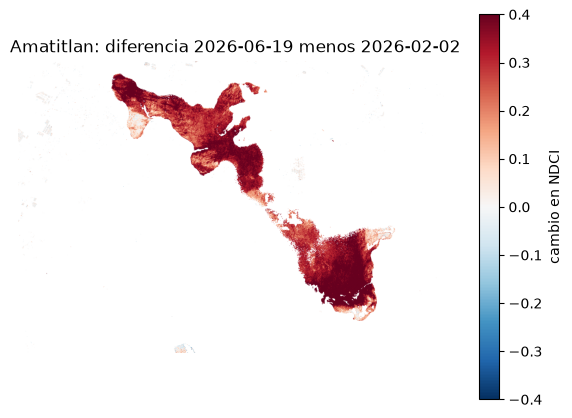

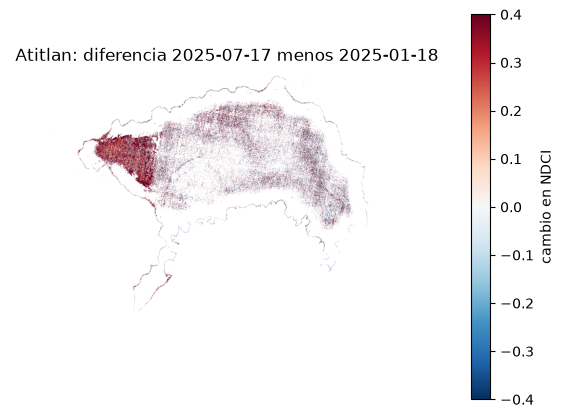

In [ ]:
for lago, g in df.groupby("lago"):
    fecha_max = g.loc[g["cyano_ndci"].idxmax(), "fecha"].strftime("%Y-%m-%d")
    fecha_min = g.loc[g["cyano_ndci"].idxmin(), "fecha"].strftime("%Y-%m-%d")
    fechas = lagos[lago]["fechas"]
    resta = pilas[lago][fechas.index(fecha_max)] - pilas[lago][fechas.index(fecha_min)]

    plt.figure(figsize=(7, 5))
    plt.imshow(resta, cmap="RdBu_r", vmin=-0.4, vmax=0.4)
    plt.title(f"{lago}: diferencia {fecha_max} menos {fecha_min}")
    plt.colorbar(label="cambio en NDCI")
    plt.axis("off")
    plt.show()

Patrón estacional: en Guatemala la época lluviosa va de mayo a octubre y la seca de noviembre a abril

                        mean  count
lago      epoca                    
Amatitlan lluviosa  0.396820      1
          seca      0.199146     10
Atitlan   lluviosa  0.003989      3
          seca     -0.036767      8 



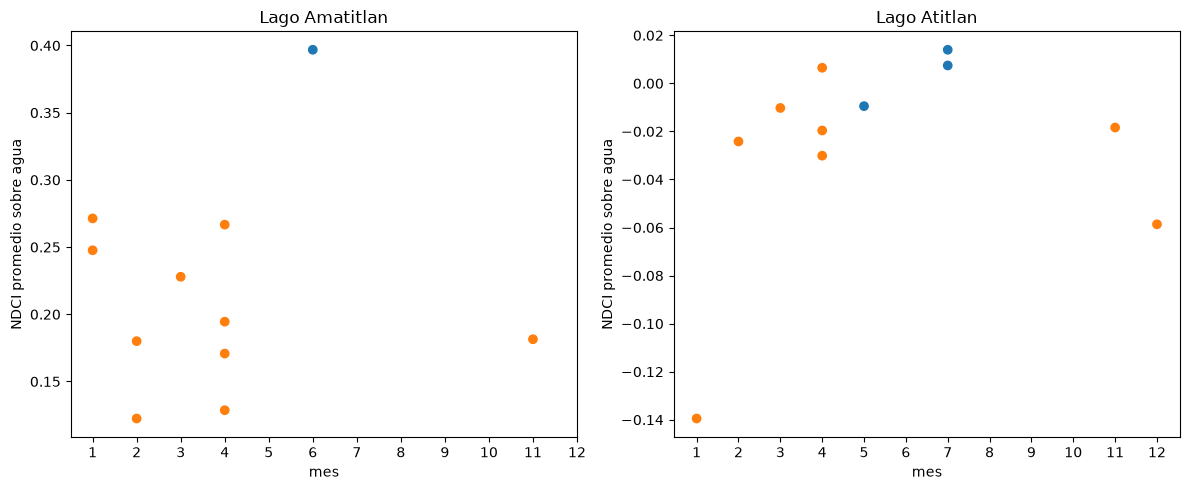

In [ ]:
df["epoca"] = np.where(df["fecha"].dt.month.between(5, 10), "lluviosa", "seca")
print(df.groupby(["lago", "epoca"])["cyano_ndci"].agg(["mean", "count"]), "\n")

fig, ejes = plt.subplots(1, 2, figsize=(12, 5))
for eje, (lago, g) in zip(ejes, df.groupby("lago")):
    eje.scatter(g["fecha"].dt.month, g["cyano_ndci"],
                c=np.where(g["epoca"] == "lluviosa", "tab:blue", "tab:orange"))
    eje.set_title(f"Lago {lago}")
    eje.set_xlabel("mes")
    eje.set_ylabel("NDCI promedio sobre agua")
    eje.set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

## Interpretación del análisis exploratorio

- La extensión de la floración confirma la diferencia entre lagos: en Amatitlán el porcentaje de agua con NDCI sobre 0.2 va del 15% en febrero de 2026 al 88% en abril de 2026, y 6 de las 11 fechas superan el 40%. En Atitlán los valores van de 0.5 a 24%, pero los cuatro más altos, que son 24.2% en enero de 2025, 12.9 en noviembre de 2025, 6.0 en febrero de 2026 y 4.4 en diciembre de 2025, coinciden exactamente con las cuatro imágenes que tienen menos píxeles válidos por bruma y sombra. Son artefactos y no floraciones.

- Las zonas persistentes tienen un significado ambiental claro: la cuenca norte de Amatitlán supera el umbral en cerca del 71% de las fechas frente al 44% de la mitad sur, siempre en el mismo lugar, lo que indica una entrada crónica de nutrientes y no un episodio pasajero. Esa es además la ribera más expuesta para el uso recreativo y para la población cercana, así que es donde tendría más sentido concentrar el muestreo y las alertas.

- Los boxplots muestran que en Amatitlán lo que cambia entre fechas es la distribución completa y no unos pocos píxeles extremos: la mediana pasa de 0.121 en febrero de 2026 a 0.455 en junio de 2026, y el mapa de diferencia entre esas dos fechas es positivo en toda la superficie. Es una floración que cubre el lago entero. En Atitlán las distribuciones son estrechas y centradas en cero en todas las fechas.

- Sobre la estacionalidad los datos no alcanzan para concluir: Amatitlán tiene 10 de sus 11 fechas en época seca y una sola en época lluviosa, que resulta ser el máximo del periodo, y Atitlán tiene 3 fechas lluviosas con un promedio apenas superior al de las secas, 0.004 contra menos 0.037. La dirección es la esperada, porque la lluvia arrastra nutrientes y el agua está más cálida, pero con una sola observación no se puede sostener. Lo que sí queda demostrado es que en Amatitlán todas las fechas, incluidas las secas, tienen floración, de modo que el problema es crónico antes que estacional.

- En conjunto, estos resultados agregan tres cosas al análisis temporal: dicen dónde ocurre la floración y que esa ubicación es estable, muestran que el fenómeno abarca al lago completo y no unos parches, y permiten separar las señales reales de los artefactos de las imágenes con bruma, que era el principal riesgo de interpretar solo el promedio por fecha.

## Del raster al formato tabular

Cada imagen es una malla de píxeles de 10 por 10 metros. Para poder trabajar los datos con herramientas
tabulares se convierte cada píxel en una fila con sus cuatro bandas, sus coordenadas geográficas y los índices.
Las coordenadas se calculan una sola vez por lago, porque todas las fechas comparten la misma malla.

In [ ]:
COORDENADAS = {}


def coordenadas(lago):
    """Longitud y latitud del centro de cada píxel de la malla del lago."""
    if lago not in COORDENADAS:
        with rasterio.open(f"{DATA_DIR}/{lago}_{lagos[lago]['fechas'][0]}.tif") as src:
            t = src.transform
            x = t.c + t.a * (np.arange(src.width) + 0.5)
            y = t.f + t.e * (np.arange(src.height) + 0.5)
            malla_x, malla_y = np.meshgrid(x, y)
            lon, lat = a_geograficas(src.crs, "EPSG:4326", malla_x.ravel(), malla_y.ravel())
        COORDENADAS[lago] = (np.array(lon), np.array(lat))
    return COORDENADAS[lago]


def raster_a_dataframe(lago, fecha, solo_agua=True):
    """Convierte una imagen en una tabla de un renglón por píxel."""
    with rasterio.open(f"{DATA_DIR}/{lago}_{fecha}.tif") as src:
        datos = src.read().astype("float32")

    datos[datos <= 0] = np.nan
    b03, b04, b05, b08 = datos / 10000
    lon, lat = coordenadas(lago)
    ndwi = nd(b03, b08)

    tabla = pd.DataFrame({
        "B03": b03.ravel(), "B04": b04.ravel(), "B05": b05.ravel(), "B08": b08.ravel(),
        "lon": lon, "lat": lat,
        "NDVI": nd(b08, b04).ravel(), "NDWI": ndwi.ravel(), "NDCI": nd(b05, b04).ravel(),
    })
    if solo_agua:
        tabla = tabla[ndwi.ravel() > 0]

    tabla = tabla.dropna().reset_index(drop=True)  # descarta nodata y reflectancias no válidas
    tabla["lago"] = pd.Categorical([lago] * len(tabla))
    tabla["fecha"] = pd.Categorical([fecha] * len(tabla))
    return tabla

Ejemplo con la fecha de mayor floración de Amatitlán.

In [ ]:
tabla = raster_a_dataframe("Amatitlan", "2026-06-19")
print(f"{len(tabla):,} píxeles de agua, {tabla.memory_usage(deep=True).sum() / 1e6:.0f} MB en memoria")
tabla.head()

157,293 píxeles de agua, 7 MB en memoria


,B03,B04,B05,B08,lon,lat,NDVI,NDWI,NDCI,lago,fecha
0,0.3044,0.2969,0.2441,0.2874,-90.601534,14.494712,-0.016259,0.028726,-0.097597,Amatitlan,2026-06-19
1,0.2317,0.2520,0.2566,0.2281,-90.601441,14.494711,-0.049781,0.007829,0.009044,Amatitlan,2026-06-19
2,0.2749,0.2522,0.2666,0.2507,-90.586977,14.494563,-0.002983,0.046043,0.027756,Amatitlan,2026-06-19
3,0.3154,0.3530,0.2666,0.2855,-90.586884,14.494562,-0.105717,0.049759,-0.139445,Amatitlan,2026-06-19
4,0.1974,0.1816,0.2107,0.1851,-90.586792,14.494561,0.009545,0.032157,0.074178,Amatitlan,2026-06-19


In [ ]:
tabla.describe().round(3)

,B03,B04,B05,B08,lon,lat,NDVI,NDWI,NDCI
count,157293.000,157293.000,157293.000,157293.000,157293.000,157293.000,157293.000,157293.000,157293.000
mean,0.099,0.066,0.101,0.060,-90.571,14.459,-0.139,0.472,0.397
std,0.128,0.133,0.117,0.122,0.026,0.021,0.269,0.240,0.181
min,0.001,0.002,0.005,0.000,-90.639,14.412,-0.991,0.000,-0.538
25%,0.056,0.020,0.052,0.012,-90.587,14.440,-0.305,0.326,0.349
50%,0.061,0.023,0.071,0.022,-90.570,14.463,-0.072,0.474,0.455
75%,0.068,0.030,0.085,0.034,-90.548,14.478,0.034,0.654,0.517
max,1.355,1.145,0.930,1.115,-90.512,14.495,0.830,0.997,0.943


Cada fecha se guarda en su propio archivo Parquet, que conserva los tipos de dato y pesa mucho menos que
un CSV. Para reconstruir la tabla completa basta leer la carpeta entera con `pd.read_parquet("tabular")`.

In [ ]:
TABULAR = "tabular"
os.makedirs(TABULAR, exist_ok=True)

for lago, info in lagos.items():
    for fecha in info["fechas"]:
        ruta = f"{TABULAR}/{lago}_{fecha}.parquet"
        raster_a_dataframe(lago, fecha).to_parquet(ruta, index=False, compression="zstd")
        print(lago, fecha, f"{os.path.getsize(ruta) / 1e6:.1f} MB")

Atitlan 2025-01-18 6.7 MB


Atitlan 2025-04-13 29.7 MB


Atitlan 2025-05-13 36.2 MB


Atitlan 2025-07-17 30.5 MB


Atitlan 2025-11-21 24.8 MB


...

Amatitlan 2025-04-15 4.9 MB
Amatitlan 2025-04-28 5.1 MB


Amatitlan 2025-11-24 4.5 MB
Amatitlan 2026-01-08 4.3 MB


Amatitlan 2026-02-02 4.2 MB
Amatitlan 2026-02-07 4.2 MB


Amatitlan 2026-03-29 5.2 MB
Amatitlan 2026-04-13 5.3 MB


Amatitlan 2026-04-28 4.8 MB
Amatitlan 2026-06-19 5.3 MB


In [ ]:
prueba = pd.read_parquet(f"{TABULAR}/Amatitlan_2026-06-19.parquet")
print(prueba.dtypes.to_string())
print(f"\n{len(prueba):,} filas leídas de vuelta")

B03       float32
B04       float32
B05       float32
B08       float32
lon       float64
lat       float64
NDVI      float32
NDWI      float32
NDCI      float32
lago     category
fecha    category

157,293 filas leídas de vuelta


Tres decisiones sobre el formato:

- Se guardan solo los píxeles de agua, que es donde tiene sentido el índice de cianobacteria. La función acepta
  `solo_agua=False` para exportar la escena completa, que en Atitlán son unos 4.8 millones de renglones por fecha
  en lugar de 1.2 millones.
- Las bandas quedan como reflectancia entre 0 y 1 en `float32`, mientras que la longitud y la latitud se guardan
  en `float64`: con `float32` el error de redondeo sería de varios metros, comparable al tamaño del píxel.
- Se incluye el NDCI además del NDVI y el NDWI, y las columnas `lago` y `fecha` como categorías, para poder
  concatenar varias fechas sin duplicar texto en memoria.

# Parte II: modelos para identificar zonas con alta presencia de cianobacteria

Con las mismas imágenes de la Parte I se arma un conjunto de datos donde cada observación es un píxel de
10 por 10 metros dentro de alguno de los dos lagos, se construye una variable respuesta binaria de alta
presencia de cianobacteria y se define el conjunto de variables predictoras.

## Construcción del conjunto de datos

Una observación es válida cuando cumple cuatro condiciones: cae dentro del cuerpo de agua permanente del lago,
en esa fecha es agua, tiene reflectancia válida en las cuatro bandas y no está tapada por nube, bruma o reflejo
del sol. El cuerpo de agua permanente se define como los píxeles que son agua en al menos 9 de las 11 fechas, lo
que deja fuera las sombras de las laderas y los charcos temporales que el NDWI confunde con lago.

In [ ]:
from scipy import ndimage
from scipy.optimize import brentq

CUERPO, DISTANCIA = {}, {}

for lago in lagos:
    permanente = np.sum(~np.isnan(pilas[lago]), axis=0) >= 9
    CUERPO[lago] = permanente
    DISTANCIA[lago] = ndimage.distance_transform_edt(permanente) * 10  # metros hasta la orilla
    print(f"{lago}: {permanente.sum():,} píxeles de lago ({permanente.sum() * 100 / 1e6:.1f} km2)")

Atitlan: 1,020,727 píxeles de lago (102.1 km2)
Amatitlan: 143,192 píxeles de lago (14.3 km2)


Además de las bandas y los índices se construyen cinco variables nuevas, tres espectrales y dos espaciales,
que se justifican más adelante.

In [ ]:
MAX_B08 = 0.10   # sobre agua limpia el infrarrojo cercano es casi nulo; por encima hay nube, bruma o reflejo
MIN_REFL = 0.001  # por debajo de una unidad de reflectancia el píxel es sombra, no agua medible


def media_local(x, k=5):
    """Promedio en una ventana de k por k píxeles, ignorando los que no tienen dato."""
    valido = ~np.isnan(x)
    suma = ndimage.uniform_filter(np.nan_to_num(x), size=k)
    cuenta = ndimage.uniform_filter(valido.astype("float32"), size=k)
    return np.where(cuenta > 0, suma / np.maximum(cuenta, 1e-6), np.nan)


def observaciones(lago, fecha):
    """Tabla de observaciones válidas del lago en esa fecha, una por píxel."""
    with rasterio.open(f"{DATA_DIR}/{lago}_{fecha}.tif") as src:
        datos = src.read().astype("float32")

    datos[datos <= 0] = np.nan
    b03, b04, b05, b08 = datos / 10000
    ndwi, ndvi, ndci = nd(b03, b08), nd(b08, b04), nd(b05, b04)
    textura = np.sqrt(np.maximum(media_local(ndwi**2) - media_local(ndwi)**2, 0))
    lon, lat = coordenadas(lago)

    valida = (CUERPO[lago] & (ndwi > 0) & (b08 < MAX_B08)
              & (b03 > MIN_REFL) & (b04 > MIN_REFL) & (b05 > MIN_REFL)
              & ~np.isnan(b03 + b04 + b05 + b08)).ravel()

    return pd.DataFrame({
        "lago": pd.Categorical([lago] * int(valida.sum())),
        "fecha": pd.Categorical([fecha] * int(valida.sum())),
        "lon": lon[valida], "lat": lat[valida],
        "B03": b03.ravel()[valida], "B04": b04.ravel()[valida],
        "B05": b05.ravel()[valida], "B08": b08.ravel()[valida],
        "NDVI": ndvi.ravel()[valida], "NDWI": ndwi.ravel()[valida], "NDCI": ndci.ravel()[valida],
        "chla": np.clip(826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071, 0, 500).ravel()[valida],
        "verde_rojo": (b03 / b04).ravel()[valida],
        "nir_verde": (b08 / b03).ravel()[valida],
        "brillo": ((b03 + b04 + b08) / 3).ravel()[valida],
        "textura_ndwi": textura.ravel()[valida],
        "dist_orilla": DISTANCIA[lago].ravel()[valida],
    })

El censo completo pasa de los 12 millones de observaciones, demasiado para entrenar y validar en tiempo
razonable. Se conserva una de cada 25, con la misma fracción en todas las fechas, de modo que la muestra
mantiene la proporción real entre lagos, entre fechas y entre clases.

In [ ]:
FRACCION = 0.04
COBERTURA_MINIMA = 50  # una fecha con menos de la mitad del lago utilizable no entra al modelado
conteos, muestras = [], []

for lago, info in lagos.items():
    for fecha in info["fechas"]:
        tabla = observaciones(lago, fecha)
        cobertura = 100 * len(tabla) / CUERPO[lago].sum()
        conteos.append({
            "lago": lago, "fecha": fecha,
            "px_del_lago": int(CUERPO[lago].sum()),
            "observaciones": len(tabla),
            "cobertura_pct": cobertura,
            "faltantes_pct": 100 * tabla.isna().to_numpy().mean(),
            "usada": cobertura >= COBERTURA_MINIMA,
        })
        if cobertura >= COBERTURA_MINIMA:
            muestras.append(tabla.sample(frac=FRACCION, random_state=0))

censo = pd.DataFrame(conteos)
ml = pd.concat(muestras, ignore_index=True)
ml["lago"] = ml["lago"].astype("category")
ml["fecha"] = ml["fecha"].astype("category")

descartadas = censo.loc[~censo["usada"], ["lago", "fecha", "cobertura_pct"]]
print(f"censo completo:    {censo['observaciones'].sum():,} observaciones")
print(f"muestra a modelar: {len(ml):,} observaciones de {int(censo['usada'].sum())} de las 22 fechas")
print(f"fechas fuera por cobertura:\n{descartadas.to_string(index=False)}")
censo.round(2)

censo completo:    11,292,821 observaciones
muestra a modelar: 450,499 observaciones de 21 de las 22 fechas
fechas fuera por cobertura:
   lago      fecha  cobertura_pct
Atitlan 2025-01-18       2.977878


,lago,fecha,px_del_lago,observaciones,cobertura_pct,faltantes_pct,usada
0,Atitlan,2025-01-18,1020727,30396,2.98,0.0,False
1,Atitlan,2025-04-13,1020727,1020348,99.96,0.0,True
2,Atitlan,2025-05-13,1020727,1020396,99.97,0.0,True
3,Atitlan,2025-07-17,1020727,1008883,98.84,0.0,True
4,Atitlan,2025-11-21,1020727,823210,80.65,0.0,True
5,Atitlan,2025-12-29,1020727,957488,93.80,0.0,True
6,Atitlan,2026-02-12,1020727,889644,87.16,0.0,True
7,Atitlan,2026-03-24,1020727,1020359,99.96,0.0,True
8,Atitlan,2026-04-13,1020727,1019677,99.90,0.0,True
9,Atitlan,2026-04-28,1020727,1020192,99.95,0.0,True


In [ ]:
print("Observaciones por lago")
print(censo.groupby("lago")["observaciones"].agg(fechas="count", total="sum").to_string(), "\n")

print("Variables disponibles, tipo y valores faltantes")
resumen = pd.DataFrame({"tipo": ml.dtypes.astype(str), "faltantes_pct": ml.isna().mean().mul(100).round(3)})
print(resumen.to_string())

Observaciones por lago
           fechas    total
lago                      
Amatitlan      11  1465865
Atitlan        11  9826956 

Variables disponibles, tipo y valores faltantes
                  tipo  faltantes_pct
lago          category            0.0
fecha         category            0.0
lon            float64            0.0
lat            float64            0.0
B03            float32            0.0
B04            float32            0.0
B05            float32            0.0
B08            float32            0.0
NDVI           float32            0.0
NDWI           float32            0.0
NDCI           float32            0.0
chla           float32            0.0
verde_rojo     float32            0.0
nir_verde      float32            0.0
brillo         float32            0.0
textura_ndwi   float32            0.0
dist_orilla    float64            0.0


### Decisiones de preparación y limpieza

- Se trabaja únicamente dentro del cuerpo de agua permanente. Filtrar solo por NDWI positivo, como en la Parte I,
  dejaba entrar sombras de las paredes del cráter de Atitlán, que es justo lo que contaminaba la imagen del 18 de
  enero de 2025.
- Se descartan los píxeles con reflectancia cero o negativa, que son el nodata del producto y los artefactos de la
  corrección atmosférica.
- Se descartan los píxeles con B08 por encima de 0.10. El agua absorbe casi todo el infrarrojo cercano, así que un
  valor alto indica nube, bruma o reflejo especular del sol.
- Se descartan también los píxeles con reflectancia por debajo de 0.001 en el verde, el rojo o el borde rojo. Son
  las sombras profundas de las paredes del cráter de Atitlán, y además hacen explotar los cocientes espectrales,
  porque dividir entre un valor casi nulo produce cifras sin sentido físico.
- Una fecha entra al modelado solo si conserva al menos la mitad del lago después de todos los filtros. La regla
  deja fuera una sola imagen, la de Atitlán del 18 de enero de 2025, que ya en la Parte I había resultado
  inservible por las sombras del sol bajo de enero: lo que sobrevive de ella no es agua bien medida.
- No se imputa nada. Después de estos filtros no quedan valores faltantes, porque cualquier píxel incompleto se
  elimina en lugar de rellenarse: inventar reflectancia en un píxel tapado por una nube produciría una observación
  que no corresponde a ninguna medición real.
- El muestreo es aleatorio con semilla fija y la misma fracción en cada fecha, así que es reproducible y no altera
  la proporción entre lagos, fechas ni clases.

## Variable respuesta

La respuesta es binaria: 1 cuando el píxel tiene alta presencia de cianobacteria y 0 cuando la presencia es baja o
nula. El corte se pone sobre la clorofila-a estimada, no sobre el NDCI directamente, porque la clorofila-a está en
microgramos por litro y para esa unidad sí existen umbrales publicados.

El valor elegido es 12 ug/L. La Organización Mundial de la Salud, en sus guías de calidad de agua recreativa,
organiza la vigilancia de cianobacterias en un marco de niveles de alerta: hasta 12 ug/L de clorofila-a con
dominancia de cianobacterias el estado es de vigilancia, entre 12 y 24 ug/L se entra al Nivel de Alerta 1, que ya
implica avisar al público y aumentar el monitoreo, y por encima de 24 ug/L al Nivel de Alerta 2. El mismo valor es
coherente con la clasificación trófica clásica, que ubica el límite eutrófico alrededor de 8 a 10 ug/L y el
hipereutrófico cerca de 25. Es decir, 12 ug/L es el punto donde la floración deja de ser un asunto de seguimiento
rutinario y pasa a ser un asunto de gestión.

In [ ]:
UMBRAL_CHLA = 12  # ug/L, entrada al Nivel de Alerta 1 de la OMS

ml["alta_presencia"] = (ml["chla"] >= UMBRAL_CHLA).astype(int)

equivalente = brentq(lambda x: 826.57 * x**3 - 176.43 * x**2 + 19 * x + 4.071 - UMBRAL_CHLA, -0.5, 0.9)
print(f"{UMBRAL_CHLA} ug/L de clorofila-a equivalen a un NDCI de {equivalente:.3f}\n")
print("Distribución global")
print(ml["alta_presencia"].value_counts(normalize=True).mul(100).round(2).to_string())

12 ug/L de clorofila-a equivalen a un NDCI de 0.264

Distribución global
alta_presencia
0    93.85
1     6.15


In [ ]:
print("Prevalencia de alta presencia por lago (%)")
print(ml.groupby("lago", observed=True)["alta_presencia"].agg(observaciones="size", prevalencia="mean")
        .assign(prevalencia=lambda t: (100 * t["prevalencia"]).round(2)).to_string(), "\n")

por_fecha = (ml.groupby(["lago", "fecha"], observed=True)["alta_presencia"]
               .mean().mul(100).round(1).rename("prevalencia_pct").reset_index())
print(por_fecha.to_string(index=False))

Prevalencia de alta presencia por lago (%)
           observaciones  prevalencia
lago                                 
Amatitlan          58636        39.94
Atitlan           391863         1.10 

     lago      fecha  prevalencia_pct
Amatitlan 2025-01-28             51.2
Amatitlan 2025-04-15             13.8
Amatitlan 2025-04-28             29.4
Amatitlan 2025-11-24             22.0
Amatitlan 2026-01-08             65.6
Amatitlan 2026-02-02              2.3
Amatitlan 2026-02-07             12.2
Amatitlan 2026-03-29             38.3
Amatitlan 2026-04-13             65.0
Amatitlan 2026-04-28             43.6
Amatitlan 2026-06-19             95.5
  Atitlan 2025-04-13              0.3
  Atitlan 2025-05-13              0.3
  Atitlan 2025-07-17              0.9
  Atitlan 2025-11-21              4.2
  Atitlan 2025-12-29              2.0
  Atitlan 2026-02-12              2.3
  Atitlan 2026-03-24              0.4
  Atitlan 2026-04-13              0.4
  Atitlan 2026-04-28              0.3
  Ati

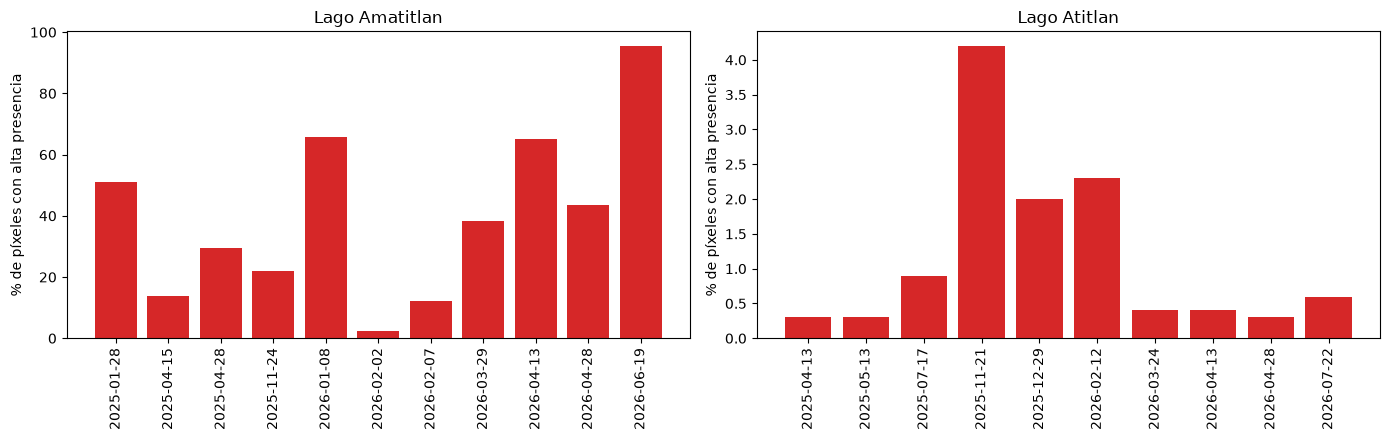

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.5))
for eje, (lago, g) in zip(ejes, por_fecha.groupby("lago", observed=True)):
    eje.bar(g["fecha"], g["prevalencia_pct"], color="tab:red")
    eje.set_title(f"Lago {lago}")
    eje.set_ylabel("% de píxeles con alta presencia")
    eje.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

### Desbalance de clases y sus consecuencias

El conjunto está claramente desbalanceado y, peor todavía, el desbalance no se reparte parejo: casi toda la clase
positiva vive en Amatitlán, mientras que Atitlán aporta sobre todo ceros. Eso tiene tres consecuencias prácticas:

- La exactitud deja de ser informativa. Un modelo que responda siempre cero acierta en la mayoría de los casos sin
  haber aprendido nada, así que hay que evaluar con precisión, recall, F1 y el área bajo la curva ROC o, mejor,
  la curva de precisión y recall, que es más sensible cuando la clase positiva es minoritaria.
- El modelo tiende a ignorar la clase minoritaria. Conviene compensar con pesos por clase, con remuestreo, o
  moviendo el umbral de decisión en lugar de dejarlo en 0.5.
- Como la clase positiva se concentra en un lago y en unas pocas fechas, una partición aleatoria deja píxeles
  vecinos de la misma imagen en entrenamiento y en prueba. Píxeles contiguos son casi idénticos, así que el modelo
  puede memorizar la imagen y las métricas saldrían infladas. La partición debería hacerse por fecha o por lago,
  no al azar.

### Variables que no pueden usarse como predictoras

La respuesta se construyó a partir de la clorofila-a, que es una transformación del NDCI, que a su vez es la
diferencia normalizada entre B05 y B04. Por lo tanto quedan fuera del conjunto de predictores:

- chla y NDCI, que son la respuesta disfrazada de variable continua.
- B05, la banda del borde rojo. Es el caso de fuga indirecta: no se usó sola para construir la respuesta, pero
  junto con B04 reconstruye el NDCI exactamente, y con eso la etiqueta.

B04 sí se conserva, porque por sí sola no permite recuperar el NDCI si B05 no está disponible. La siguiente celda
mide la fuga en lugar de solo afirmarla: se calcula el área bajo la curva ROC usando cada variable por separado
como si fuera un clasificador.

In [ ]:
from sklearn.metrics import roc_auc_score

print("Poder de separación de cada variable por sí sola (AUC)")
for v in ["NDCI", "chla", "B05", "B04", "B03", "B08", "NDVI", "NDWI"]:
    print(f"  {v:<6} {roc_auc_score(ml['alta_presencia'], ml[v]):.3f}")

Poder de separación de cada variable por sí sola (AUC)
  NDCI   1.000
  chla   1.000


  B05    0.872
  B04    0.735
  B03    0.756
  B08    0.702


  NDVI   0.550
  NDWI   0.437


## Variables predictoras

Usamos diez variables. Cinco salen directo de las imágenes: B03 en el verde, donde las cianobacterias reflejan fuerte por su pigmentación; B04 en el rojo, donde la clorofila absorbe, así que a más biomasa menos reflectancia; B08 en el infrarrojo cercano, que el agua limpia absorbe casi por completo y sube cuando hay biomasa en suspensión; y los índices NDVI y NDWI, que sobre agua indican material fotosintético flotante y qué tan limpia es la firma del agua.

Las otras cinco las construimos. verde_rojo (B03/B04) es el cociente clásico para clorofila y, al ser cociente, no depende del nivel de iluminación. nir_verde (B08/B03) separa la dispersión por partículas de la absorción por pigmento, lo que ayuda a distinguir una floración de agua turbia por sedimento. brillo es el promedio de las tres bandas y sirve de referencia para esos cocientes. textura_ndwi es la desviación estándar del NDWI en 50 por 50 metros: las floraciones son manchadas y dejan vecindarios heterogéneos, y su correlación con el NDWI es de solo 0.15, así que aporta información distinta. dist_orilla es la distancia al borde del lago, porque las floraciones se acumulan cerca de la orilla y de las desembocaduras, como vimos en la cuenca norte de Amatitlán.

Ninguna de las construidas usa B05, así que no reintroducen la fuga.

Dejamos fuera el lago, la fecha, la longitud y la latitud. No son fuga, pero con ellas el modelo memoriza en qué cuenca está el píxel en lugar de aprender la firma espectral, y en la Parte I la ubicación por sí sola ya casi determinaba la etiqueta. Las conservamos en la tabla porque las necesitamos para particionar por fecha o por lago y para volver a llevar las predicciones al mapa.

In [ ]:
PREDICTORES = ["B03", "B04", "B08", "NDVI", "NDWI",
               "verde_rojo", "nir_verde", "brillo", "textura_ndwi", "dist_orilla"]
EXCLUIDAS_POR_FUGA = ["B05", "NDCI", "chla"]
IDENTIFICADORAS = ["lago", "fecha", "lon", "lat"]

ml[PREDICTORES].describe().round(3)

,B03,B04,B08,NDVI,NDWI,verde_rojo,nir_verde,brillo,textura_ndwi,dist_orilla
count,450499.000,450499.000,450499.000,450499.000,450499.000,450499.000,450499.000,450499.000,450499.000,450499.000
mean,0.024,0.013,0.012,-0.045,0.416,2.579,0.433,0.016,0.037,951.659
std,0.016,0.011,0.011,0.144,0.171,1.399,0.171,0.012,0.038,850.124
min,0.004,0.001,0.000,-0.989,0.001,0.474,0.002,0.002,0.000,10.000
25%,0.015,0.005,0.004,-0.090,0.285,1.669,0.311,0.008,0.020,200.998
50%,0.021,0.010,0.009,-0.034,0.408,2.066,0.421,0.013,0.027,702.638
75%,0.027,0.016,0.015,0.013,0.525,3.053,0.557,0.019,0.043,1569.841
max,0.411,0.151,0.100,0.718,0.996,23.273,0.999,0.215,0.633,3157.784


Distribución de cada predictora según la clase, que es lo que el modelo tendrá que aprovechar.

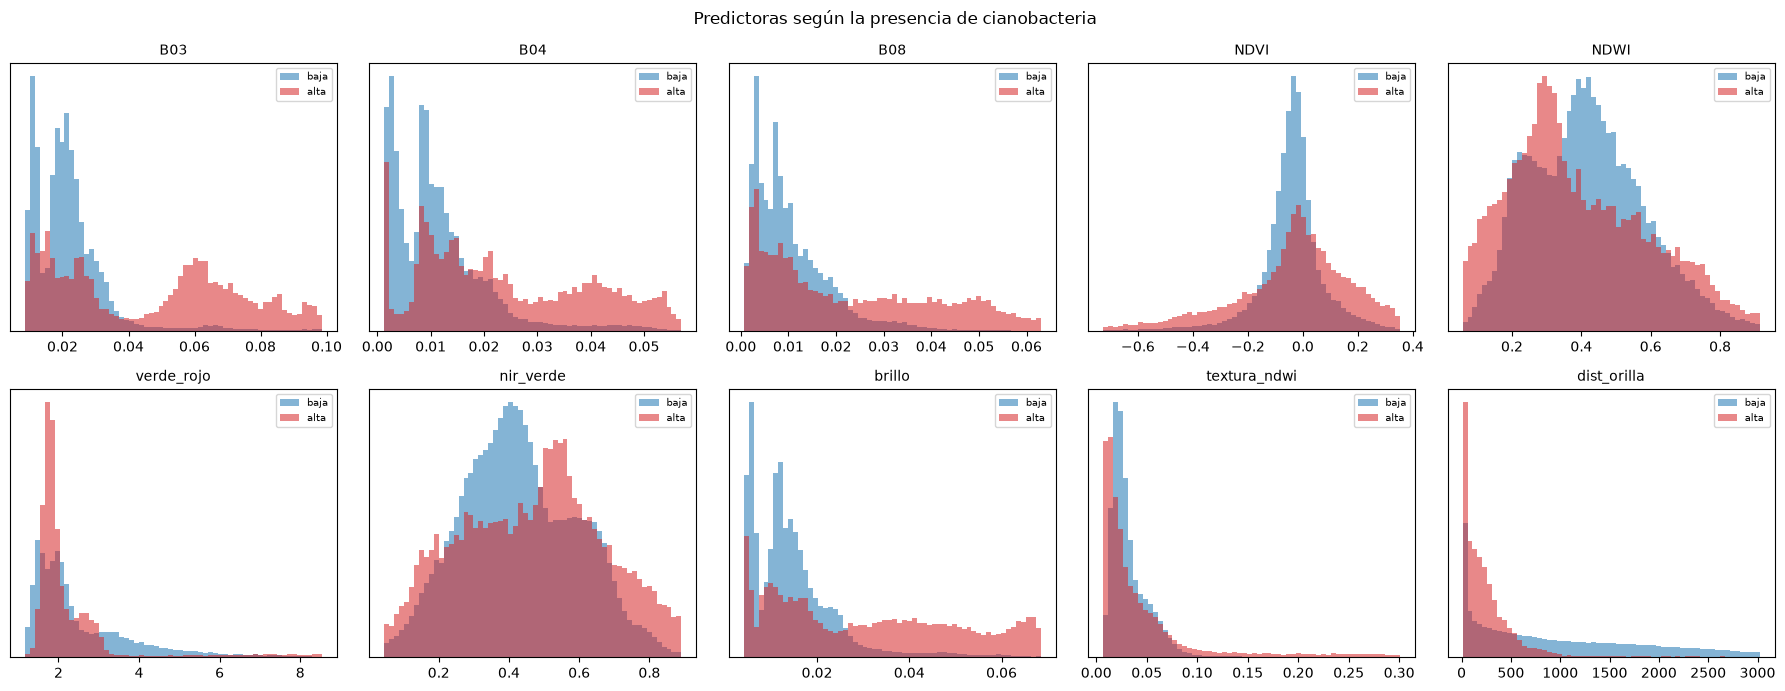

In [ ]:
fig, ejes = plt.subplots(2, 5, figsize=(18, 7))
for eje, v in zip(ejes.ravel(), PREDICTORES):
    for clase, etiqueta, color in [(0, "baja", "tab:blue"), (1, "alta", "tab:red")]:
        datos = ml.loc[ml["alta_presencia"] == clase, v]
        eje.hist(datos, bins=60, range=np.nanpercentile(ml[v], [0.5, 99.5]),
                 density=True, alpha=0.55, color=color, label=etiqueta)
    eje.set_title(v, fontsize=10)
    eje.set_yticks([])
    eje.legend(fontsize=7)

fig.suptitle("Predictoras según la presencia de cianobacteria")
plt.tight_layout()
plt.show()

In [ ]:
print("Promedio de cada predictora por clase")
print(ml.groupby("alta_presencia")[PREDICTORES].mean().round(3).T.to_string())

Promedio de cada predictora por clase
alta_presencia        0        1
B03               0.023    0.047
B04               0.012    0.024
B08               0.011    0.025
NDVI             -0.045   -0.039
NDWI              0.418    0.386
verde_rojo        2.585    2.484
nir_verde         0.430    0.476
brillo            0.015    0.032
textura_ndwi      0.036    0.059
dist_orilla     995.072  289.477


In [ ]:
print("Poder de separación de cada predictora por sí sola (AUC)")
for v in PREDICTORES:
    area = roc_auc_score(ml["alta_presencia"], ml[v])
    print(f"  {v:<13}{max(area, 1 - area):.3f}")

Poder de separación de cada predictora por sí sola (AUC)
  B03          0.756
  B04          0.735
  B08          0.702


  NDVI         0.550
  NDWI         0.563
  verde_rojo   0.542
  nir_verde    0.563


  brillo       0.745
  textura_ndwi 0.515
  dist_orilla  0.758


Ninguna predictora separa las clases por sí sola, que es justo lo que se espera después de haber quitado las
variables con fuga. Las que más aportan son las de nivel de reflectancia, `B03`, `brillo`, `B04` y `B08`, todas
alrededor de 0.75 de área bajo la curva: el agua florecida es sencillamente más brillante. La sorpresa útil es
`dist_orilla`, con 0.758, que no es información espectral sino geográfica y refleja lo que ya mostraba la Parte I,
que la floración se concentra cerca de la orilla y de la desembocadura. Los índices y los cocientes quedan cerca
de 0.55, es decir aportan poco solos, pero sirven en combinación porque describen la forma del espectro y no su
intensidad, que es lo que permite distinguir una floración de agua turbia por sedimento.

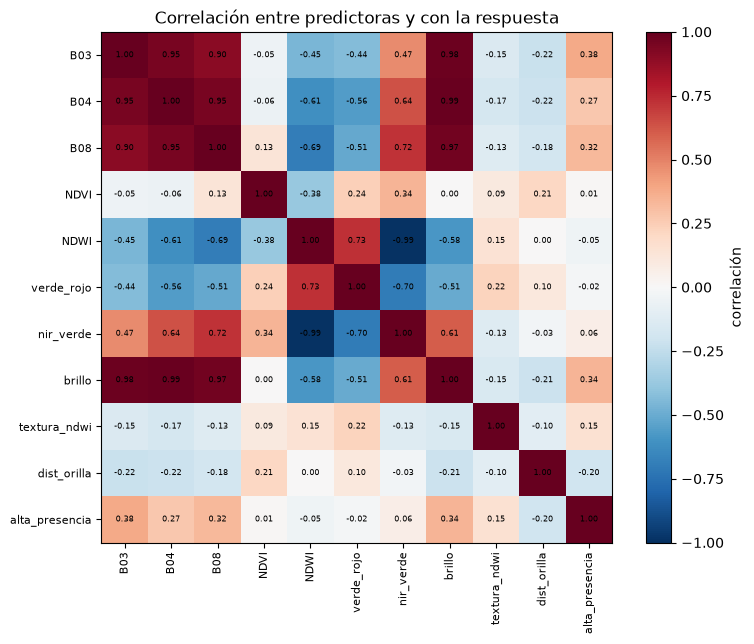

In [ ]:
corr = ml[PREDICTORES + ["alta_presencia"]].corr()

plt.figure(figsize=(8, 6.5))
plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns, rotation=90, fontsize=8)
plt.yticks(range(len(corr)), corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6)
plt.colorbar(label="correlación")
plt.title("Correlación entre predictoras y con la respuesta")
plt.tight_layout()
plt.show()

En la matriz se ve que `brillo`, `B03` y `B04` están muy correlacionadas entre sí, cosa esperable porque las
tres miden nivel de reflectancia. Para modelos de árboles eso no es problema, pero si se usa regresión logística
conviene estandarizar y tener presente que los coeficientes individuales se vuelven difíciles de interpretar.

In [ ]:
ml.to_parquet("ml_dataset.parquet", index=False, compression="zstd")
print(f"guardado ml_dataset.parquet con {len(ml):,} filas y {ml.shape[1]} columnas")
ml.head()

guardado ml_dataset.parquet con 450,499 filas y 18 columnas


,lago,fecha,lon,lat,B03,B04,B05,B08,NDVI,NDWI,NDCI,chla,verde_rojo,nir_verde,brillo,textura_ndwi,dist_orilla,alta_presencia
0,Atitlan,2025-04-13,-91.277094,14.712400,0.0258,0.0125,0.0108,0.0143,0.067164,0.286783,-0.072961,1.424494,2.064000,0.554264,0.017533,0.035533,44.721360,0
1,Atitlan,2025-04-13,-91.190348,14.714811,0.0305,0.0209,0.0181,0.0178,-0.080103,0.262940,-0.071795,1.491604,1.459330,0.583607,0.023067,0.020560,2250.777643,0
2,Atitlan,2025-04-13,-91.208590,14.698234,0.0238,0.0103,0.0110,0.0103,0.000000,0.395894,0.032864,4.534201,2.310680,0.432773,0.014800,0.018763,2617.728023,0
3,Atitlan,2025-04-13,-91.215764,14.706604,0.0246,0.0121,0.0118,0.0112,-0.038627,0.374302,-0.012552,3.803074,2.033058,0.455285,0.015967,0.017331,2369.662423,0
4,Atitlan,2025-04-13,-91.231050,14.722356,0.0245,0.0128,0.0122,0.0115,-0.053498,0.361111,-0.024000,3.501950,1.914062,0.469388,0.016267,0.014903,260.000000,0


In [6]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, fbeta_score,
                             precision_score, recall_score, roc_auc_score, RocCurveDisplay)
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV, StratifiedKFold,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

if "ml" not in globals():
    ml = pd.read_parquet("ml_dataset.parquet", engine="fastparquet")
if "PREDICTORES" not in globals():
    PREDICTORES = ["B03", "B04", "B08", "NDVI", "NDWI",
                   "verde_rojo", "nir_verde", "brillo", "textura_ndwi", "dist_orilla"]

SEMILLA = 42
X = ml[PREDICTORES].copy()
y = ml["alta_presencia"].astype(int).copy()

# Los índices se guardan para auditar que los tres modelos reciben exactamente la misma prueba.
idx_train, idx_test = train_test_split(
    np.arange(len(ml)), test_size=0.30, stratify=y, random_state=SEMILLA
)
X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
y_train, y_test = y.iloc[idx_train], y.iloc[idx_test]

print(f"Entrenamiento: {len(X_train):,} ({100*y_train.mean():.2f}% positivos)")
print(f"Prueba:        {len(X_test):,} ({100*y_test.mean():.2f}% positivos)")
print("Mismo conjunto de prueba para los tres modelos:", len(np.unique(idx_test)) == len(idx_test))

Entrenamiento: 315,349 (6.15% positivos)
Prueba:        135,150 (6.15% positivos)
Mismo conjunto de prueba para los tres modelos: True


In [7]:
def metricas_modelo(nombre, modelo, X_eval, y_eval, umbral=0.5, etapa="Inicial"):
    prob = modelo.predict_proba(X_eval)[:, 1]
    pred = (prob >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_eval, pred, labels=[0, 1]).ravel()
    return {
        "etapa": etapa, "modelo": nombre, "umbral": umbral,
        "accuracy": accuracy_score(y_eval, pred),
        "precision": precision_score(y_eval, pred, zero_division=0),
        "recall": recall_score(y_eval, pred, zero_division=0),
        "f1": f1_score(y_eval, pred, zero_division=0),
        "f2": fbeta_score(y_eval, pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, prob),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
    }


modelos_iniciales = {
    "Regresión Logística": Pipeline([
        ("escala", StandardScaler()),
        ("modelo", LogisticRegression(max_iter=1000, random_state=SEMILLA)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=250, random_state=SEMILLA, n_jobs=-1
    ),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=SEMILLA),
}

resultados_iniciales = []
for nombre, modelo in modelos_iniciales.items():
    modelo.fit(X_train, y_train)
    resultados_iniciales.append(metricas_modelo(nombre, modelo, X_test, y_test))

pd.DataFrame(resultados_iniciales).set_index("modelo").round(4)

/Users/carlosangel50/projects/lab_4_ds/Laboratorio-4---Data-Science/venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/carlosangel50/projects/lab_4_ds/Laboratorio-4---Data-Science/venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/carlosangel50/projects/lab_4_ds/Laboratorio-4---Data-Science/venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/carlosangel50/projects/lab_4_ds/Laboratorio-4---Data-Science/venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/carlosangel5

,etapa,umbral,accuracy,precision,recall,f1,f2,roc_auc,tn,fp,fn,tp
modelo,,,,,,,,,,,,
Regresión Logística,Inicial,0.5,0.9543,0.7410,0.3957,0.5159,0.4363,0.8841,125685,1150,5025,3290
Random Forest,Inicial,0.5,0.9714,0.8417,0.6593,0.7394,0.6892,0.9794,125804,1031,2833,5482
Gradient Boosting,Inicial,0.5,0.9701,0.8425,0.6317,0.7221,0.6650,0.9809,125853,982,3062,5253


In [8]:
# Submuestra estratificada destinada únicamente a la búsqueda.
if len(X_train) > 120_000:
    idx_ajuste, _ = train_test_split(
        np.arange(len(X_train)), train_size=120_000, stratify=y_train, random_state=SEMILLA
    )
    X_ajuste, y_ajuste = X_train.iloc[idx_ajuste], y_train.iloc[idx_ajuste]
else:
    X_ajuste, y_ajuste = X_train, y_train

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEMILLA)
scoring_f2 = "f1"  # se reemplaza abajo por un scorer F2 explícito
from sklearn.metrics import make_scorer
scoring_f2 = make_scorer(fbeta_score, beta=2, zero_division=0)

busquedas = {
    "Regresión Logística": GridSearchCV(
        clone(modelos_iniciales["Regresión Logística"]),
        {"modelo__C": [0.01, 0.1, 1, 10],
         "modelo__class_weight": [None, "balanced"]},
        scoring=scoring_f2, cv=cv, n_jobs=-1, refit=True,
    ),
    "Random Forest": RandomizedSearchCV(
        RandomForestClassifier(n_estimators=250, random_state=SEMILLA, n_jobs=1),
        {"max_depth": [None, 12, 24],
         "min_samples_leaf": [1, 5, 20],
         "max_features": ["sqrt", 0.7],
         "class_weight": [None, "balanced_subsample"]},
        n_iter=10, scoring=scoring_f2, cv=cv, n_jobs=-1, random_state=SEMILLA, refit=True,
    ),
    "Gradient Boosting": RandomizedSearchCV(
        HistGradientBoostingClassifier(random_state=SEMILLA),
        {"learning_rate": [0.03, 0.07, 0.12],
         "max_iter": [100, 200],
         "max_leaf_nodes": [15, 31, 63],
         "min_samples_leaf": [20, 100],
         "l2_regularization": [0.0, 1.0],
         "class_weight": [None, "balanced"]},
        n_iter=10, scoring=scoring_f2, cv=cv, n_jobs=-1, random_state=SEMILLA, refit=True,
    ),
}

mejores_parametros = {}
for nombre, busqueda in busquedas.items():
    print(f"Ajustando {nombre}...")
    busqueda.fit(X_ajuste, y_ajuste)
    mejores_parametros[nombre] = busqueda.best_params_
    print(f"  F2 CV = {busqueda.best_score_:.4f}; parámetros = {busqueda.best_params_}")

Ajustando Regresión Logística...


/Users/carlosangel50/projects/lab_4_ds/Laboratorio-4---Data-Science/venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/carlosangel50/projects/lab_4_ds/Laboratorio-4---Data-Science/venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/carlosangel50/projects/lab_4_ds/Laboratorio-4---Data-Science/venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/carlosangel50/projects/lab_4_ds/Laboratorio-4---Data-Science/venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/carlosangel50/projects/lab_4_ds/Laborato

  F2 CV = 0.5816; parámetros = {'modelo__C': 10, 'modelo__class_weight': 'balanced'}
Ajustando Random Forest...
  F2 CV = 0.7741; parámetros = {'min_samples_leaf': 20, 'max_features': 0.7, 'max_depth': 24, 'class_weight': 'balanced_subsample'}
Ajustando Gradient Boosting...
  F2 CV = 0.7644; parámetros = {'min_samples_leaf': 20, 'max_leaf_nodes': 63, 'max_iter': 200, 'learning_rate': 0.03, 'l2_regularization': 0.0, 'class_weight': 'balanced'}


In [9]:
# Separación interna para elegir umbral sin tocar la prueba final.
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=123
)
rejilla_umbrales = np.linspace(0.05, 0.95, 181)

umbrales, modelos_finales = {}, {}
for nombre, busqueda in busquedas.items():
    candidato = clone(busqueda.best_estimator_)
    candidato.fit(X_fit, y_fit)
    p_val = candidato.predict_proba(X_val)[:, 1]
    valores_f2 = [fbeta_score(y_val, p_val >= u, beta=2, zero_division=0)
                  for u in rejilla_umbrales]
    umbrales[nombre] = float(rejilla_umbrales[int(np.argmax(valores_f2))])

    final = clone(busqueda.best_estimator_)
    # Ya no hay paralelización exterior: el bosque puede usar todos los núcleos.
    if nombre == "Random Forest":
        final.set_params(n_jobs=-1)
    final.fit(X_train, y_train)
    modelos_finales[nombre] = final
    print(f"{nombre}: umbral F2 = {umbrales[nombre]:.3f}")

resultados_finales = [
    metricas_modelo(nombre, modelo, X_test, y_test, umbrales[nombre], "Ajustado")
    for nombre, modelo in modelos_finales.items()
]
resultados = pd.DataFrame(resultados_iniciales + resultados_finales)
resultados.round(4)

/Users/carlosangel50/projects/lab_4_ds/Laboratorio-4---Data-Science/venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/carlosangel50/projects/lab_4_ds/Laboratorio-4---Data-Science/venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/carlosangel50/projects/lab_4_ds/Laboratorio-4---Data-Science/venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/carlosangel50/projects/lab_4_ds/Laboratorio-4---Data-Science/venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/carlosangel5

Regresión Logística: umbral F2 = 0.600
Random Forest: umbral F2 = 0.585
Gradient Boosting: umbral F2 = 0.725


/Users/carlosangel50/projects/lab_4_ds/Laboratorio-4---Data-Science/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/carlosangel50/projects/lab_4_ds/Laboratorio-4---Data-Science/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/carlosangel50/projects/lab_4_ds/Laboratorio-4---Data-Science/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,etapa,modelo,umbral,accuracy,precision,recall,f1,f2,roc_auc,tn,fp,fn,tp
0,Inicial,Regresión Logística,0.500,0.9543,0.7410,0.3957,0.5159,0.4363,0.8841,125685,1150,5025,3290
1,Inicial,Random Forest,0.500,0.9714,0.8417,0.6593,0.7394,0.6892,0.9794,125804,1031,2833,5482
2,Inicial,Gradient Boosting,0.500,0.9701,0.8425,0.6317,0.7221,0.6650,0.9809,125853,982,3062,5253
3,Ajustado,Regresión Logística,0.600,0.9115,0.3809,0.7005,0.4935,0.5999,0.9129,117368,9467,2490,5825
4,Ajustado,Random Forest,0.585,0.9539,0.5835,0.8740,0.6998,0.7948,0.9825,121647,5188,1048,7267
5,Ajustado,Gradient Boosting,0.725,0.9498,0.5584,0.8805,0.6834,0.7894,0.9819,121046,5789,994,7321


,accuracy,precision,recall,f1,f2,roc_auc,umbral,tn,fp,fn,tp
modelo,,,,,,,,,,,
Random Forest,0.9539,0.5835,0.8740,0.6998,0.7948,0.9825,0.585,121647,5188,1048,7267
Gradient Boosting,0.9498,0.5584,0.8805,0.6834,0.7894,0.9819,0.725,121046,5789,994,7321
Regresión Logística,0.9115,0.3809,0.7005,0.4935,0.5999,0.9129,0.600,117368,9467,2490,5825


Mejor modelo según F2: Random Forest


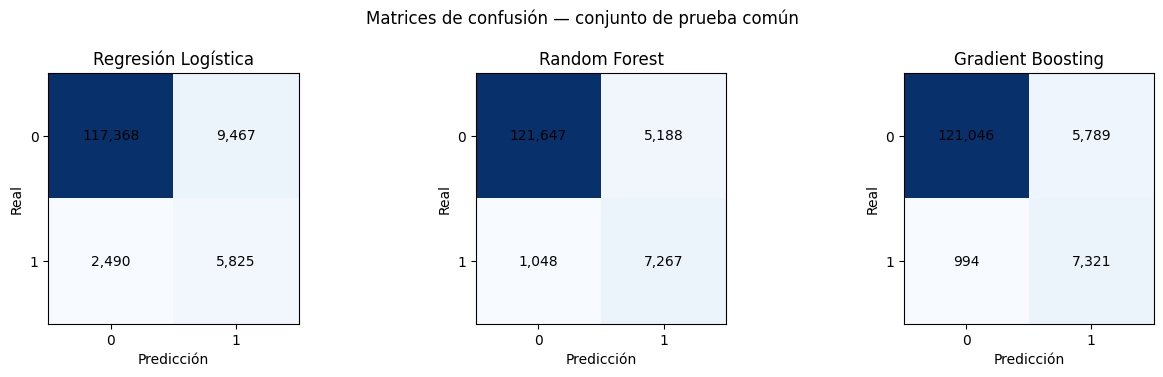

/Users/carlosangel50/projects/lab_4_ds/Laboratorio-4---Data-Science/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/carlosangel50/projects/lab_4_ds/Laboratorio-4---Data-Science/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/carlosangel50/projects/lab_4_ds/Laboratorio-4---Data-Science/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


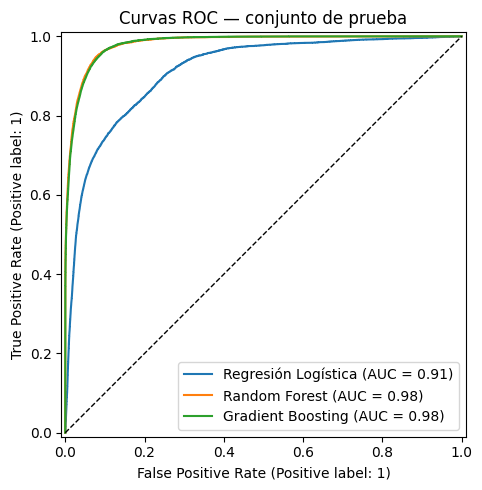

In [10]:
columnas_metricas = ["accuracy", "precision", "recall", "f1", "f2", "roc_auc"]
comparacion = (resultados[resultados["etapa"] == "Ajustado"]
               .set_index("modelo")[columnas_metricas + ["umbral", "tn", "fp", "fn", "tp"]]
               .sort_values("f2", ascending=False))
display(comparacion.round(4))

mejor_modelo = comparacion.index[0]
print(f"Mejor modelo según F2: {mejor_modelo}")

fig, ejes = plt.subplots(1, 3, figsize=(13, 3.8))
for eje, (nombre, modelo) in zip(ejes, modelos_finales.items()):
    fila = comparacion.loc[nombre]
    matriz = np.array([[fila.tn, fila.fp], [fila.fn, fila.tp]], dtype=int)
    im = eje.imshow(matriz, cmap="Blues")
    for i in range(2):
        for j in range(2):
            eje.text(j, i, f"{matriz[i, j]:,}", ha="center", va="center")
    eje.set(title=nombre, xlabel="Predicción", ylabel="Real",
            xticks=[0, 1], yticks=[0, 1])
fig.suptitle("Matrices de confusión — conjunto de prueba común")
plt.tight_layout()
plt.show()

fig, eje = plt.subplots(figsize=(6, 5))
for nombre, modelo in modelos_finales.items():
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, name=nombre, ax=eje)
eje.plot([0, 1], [0, 1], "k--", lw=1)
eje.set_title("Curvas ROC — conjunto de prueba")
plt.tight_layout()
plt.show()

In [11]:
from pathlib import Path

os.makedirs("figuras", exist_ok=True)
resultados.to_csv("resultados_modelos.csv", index=False)
pd.DataFrame([
    {"modelo": nombre, "hiperparametros": repr(params), "umbral": umbrales[nombre]}
    for nombre, params in mejores_parametros.items()
]).to_csv("hiperparametros_modelos.csv", index=False)

BS = chr(92)

def tex_escape(texto):
    return (str(texto).replace(BS, BS + "textbackslash{}")
            .replace("&", BS + "&").replace("%", BS + "%")
            .replace("_", BS + "_").replace("#", BS + "#"))

lineas = [
    BS + "subsection{Resultados de clasificación}",
    "Los tres modelos se evaluaron sobre el mismo 30" + BS +
    "% de prueba. La configuración y el umbral se eligieron sin utilizar esas observaciones.",
    BS + "begin{table}[H]", BS + "centering", BS + "small",
    BS + "begin{tabular}{lrrrrrr}", BS + "toprule",
    "Modelo & Accuracy & Precision & Recall & F1 & F2 & ROC-AUC " + BS * 2, BS + "midrule",
]
for nombre, fila in comparacion.iterrows():
    lineas.append(f"{tex_escape(nombre)} & {fila.accuracy:.3f} & {fila.precision:.3f} & "
                  f"{fila.recall:.3f} & {fila.f1:.3f} & {fila.f2:.3f} & {fila.roc_auc:.3f} " + BS * 2)
lineas += [BS + "bottomrule", BS + "end{tabular}",
           BS + "caption{Desempeño final sobre el conjunto de prueba común.}", BS + "end{table}"]

lineas += [BS + "begin{table}[H]", BS + "centering", BS + "small",
           BS + "begin{tabular}{lrrrrr}", BS + "toprule",
           "Modelo & Umbral & TN & FP & FN & TP " + BS * 2, BS + "midrule"]
for nombre, fila in comparacion.iterrows():
    lineas.append(f"{tex_escape(nombre)} & {fila.umbral:.3f} & {int(fila.tn)} & {int(fila.fp)} & "
                  f"{int(fila.fn)} & {int(fila.tp)} " + BS * 2)
lineas += [BS + "bottomrule", BS + "end{tabular}",
           BS + "caption{Matrices de confusión expresadas como conteos.}", BS + "end{table}"]

fila_mejor = comparacion.loc[mejor_modelo]
lineas.append(
    f"Según F2, el mejor modelo es {BS}textbf{{{tex_escape(mejor_modelo)}}}, con F2={fila_mejor.f2:.3f}, "
    f"recall={fila_mejor.recall:.3f} y precision={fila_mejor.precision:.3f}."
)
lineas.append(
    "Se priorizó reducir falsos negativos porque omitir una zona afectada retrasa la alerta y puede mantener la "
    "exposición. Los falsos positivos implican inspecciones y alertas innecesarias, pero su consecuencia suele ser "
    "reversible; F2 equilibra esta prioridad sin aceptar una precisión arbitrariamente baja."
)
Path("resultados_modelos.tex").write_text("\n".join(lineas) + "\n", encoding="utf-8")
print("Se generaron resultados_modelos.csv, hiperparametros_modelos.csv y resultados_modelos.tex")

Se generaron resultados_modelos.csv, hiperparametros_modelos.csv y resultados_modelos.tex


## Validación espacial

Las observaciones cercanas en el espacio comparten condiciones de iluminación, profundidad y aporte de
nutrientes, así que un modelo puede parecer mejor de lo que es si el conjunto de prueba tiene píxeles vecinos
de los que ya vio en entrenamiento. Para medir esto se reproyectan las coordenadas a un sistema métrico, se
arma una cuadrícula de bloques y se fuerza a que todas las observaciones de un mismo bloque queden en el mismo
lado de la partición.

In [9]:
from pyproj import Transformer

transformador_utm = Transformer.from_crs("EPSG:4326", "EPSG:32615", always_xy=True)
ml["x"], ml["y"] = transformador_utm.transform(ml["lon"].to_numpy(), ml["lat"].to_numpy())

for lago, g in ml.groupby("lago", observed=True):
    print(f"{lago}: x [{g.x.min():,.0f}, {g.x.max():,.0f}] m, "
          f"y [{g.y.min():,.0f}, {g.y.max():,.0f}] m, "
          f"extension {(g.x.max()-g.x.min())/1000:.1f} x {(g.y.max()-g.y.min())/1000:.1f} km")

Amatitlan: x [755,185, 766,375] m, y [1,594,635, 1,603,385] m, extension 11.2 x 8.8 km
Atitlan: x [684,465, 702,925] m, y [1,616,255, 1,631,245] m, extension 18.5 x 15.0 km


Se usa WGS 84 / UTM zona 15N (EPSG:32615), que corresponde a la longitud de ambos lagos
(entre 90.5° y 91.3° oeste) y da coordenadas en metros, necesarias para definir bloques de tamaño fijo.

In [10]:
TAMANOS_PRUEBA = [500, 1000, 1500, 2000]
resumen_tam = []

for tam in TAMANOS_PRUEBA:
    for lago, g in ml.groupby("lago", observed=True):
        bx = np.floor(g["x"] / tam).astype(int)
        by = np.floor(g["y"] / tam).astype(int)
        conteo = (bx.astype(str) + "_" + by.astype(str)).value_counts()
        resumen_tam.append({
            "tamano_m": tam, "lago": lago, "n_bloques": len(conteo),
            "obs_min": int(conteo.min()), "obs_mediana": int(conteo.median()),
            "obs_max": int(conteo.max()),
            "pct_bloques_menos_5_obs": round(100 * (conteo < 5).mean(), 1),
        })

resumen_tam = pd.DataFrame(resumen_tam)
resumen_tam

,tamano_m,lago,n_bloques,obs_min,obs_mediana,obs_max,pct_bloques_menos_5_obs
0,500,Amatitlan,107,2,524,1155,5.6
1,500,Atitlan,571,1,938,1081,1.1
2,1000,Amatitlan,39,2,1085,4438,2.6
3,1000,Atitlan,164,4,3279,4077,0.6
4,1500,Amatitlan,23,2,2374,7953,4.3
5,1500,Atitlan,83,10,5393,9037,0.0
6,2000,Amatitlan,19,5,1129,14154,0.0
7,2000,Atitlan,51,4,4973,16028,2.0


Con bloques de 500 m hay muchos bloques (107 en Amatitlán, 571 en Atitlán), pero el 5.6% de los de
Amatitlán queda con menos de 5 observaciones, lo que deja folds ruidosos. Con 2000 m ocurre lo contrario: pocos
bloques (19 y 51) y muy desiguales, un solo bloque llega a concentrar entre 14,000 y 16,000 observaciones mientras
otros tienen menos de 10, lo que produce folds de tamaño muy distinto. El tamaño de 1000 m, el que pide el
enunciado, resulta ser también el mejor balance con estos datos: 39 bloques en Amatitlán y 164 en Atitlán, más que
suficientes para un GroupKFold de 5 particiones con varios bloques por fold en ambos lagos, y solo 2.6% y 0.6% de
los bloques quedan con menos de 5 observaciones. Se usa 1000 m para el resto del análisis.

In [11]:
TAM_BLOQUE = 1000  # metros


def asignar_bloques(df, tam=TAM_BLOQUE):
    bx = np.floor(df["x"] / tam).astype(int)
    by = np.floor(df["y"] / tam).astype(int)
    return df["lago"].astype(str) + "_" + bx.astype(str) + "_" + by.astype(str)


ml["bloque_espacial"] = asignar_bloques(ml)

resumen_bloques = ml.groupby(["lago", "bloque_espacial"], observed=True).size().rename("n_obs").reset_index()
print("Bloques por lago:")
print(resumen_bloques.groupby("lago", observed=True)["bloque_espacial"].nunique().to_string())
print("\nObservaciones por bloque:")
print(resumen_bloques.groupby("lago", observed=True)["n_obs"].describe().round(1).to_string())

Bloques por lago:
lago
Amatitlan     39
Atitlan      164

Observaciones por bloque:
           count    mean     std  min    25%     50%     75%     max
lago                                                                
Amatitlan   39.0  1503.5  1375.1  2.0  218.5  1085.0  2487.5  4438.0
Atitlan    164.0  2389.4  1614.2  4.0  605.0  3279.5  3913.5  4077.0


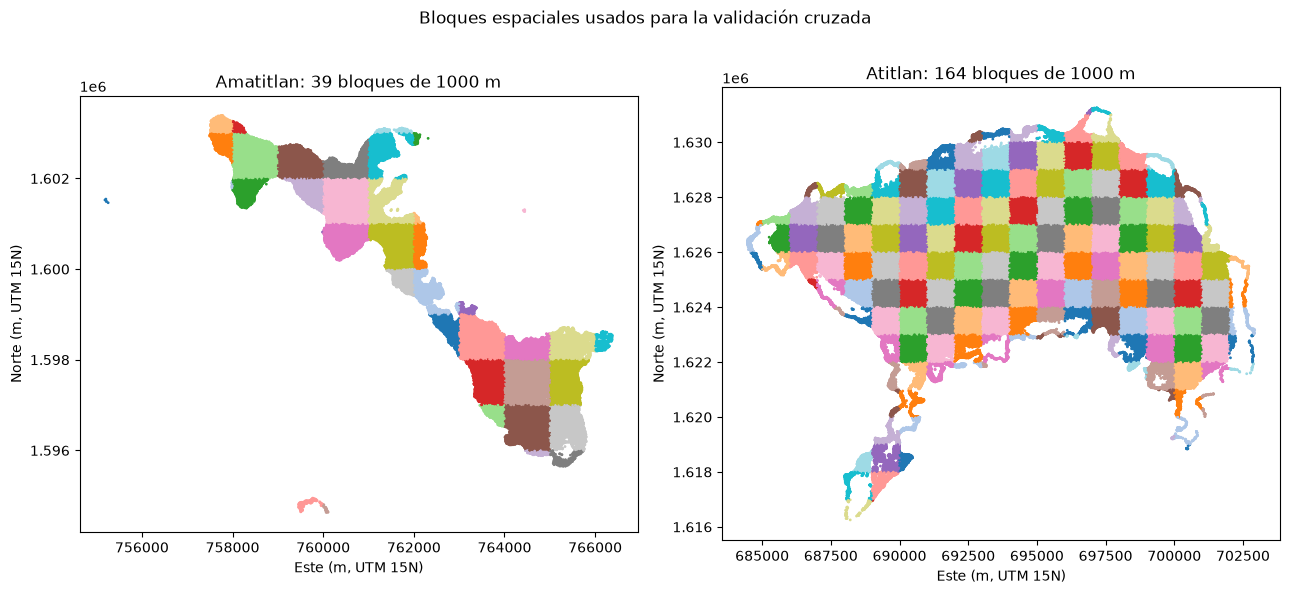

In [12]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 6))
for eje, (lago, g) in zip(ejes, ml.groupby("lago", observed=True)):
    codigos = g["bloque_espacial"].astype("category").cat.codes
    eje.scatter(g["x"], g["y"], c=codigos % 20, cmap="tab20", s=1)
    eje.set_title(f"{lago}: {g['bloque_espacial'].nunique()} bloques de {TAM_BLOQUE} m")
    eje.set_xlabel("Este (m, UTM 15N)")
    eje.set_ylabel("Norte (m, UTM 15N)")
    eje.set_aspect("equal")
fig.suptitle("Bloques espaciales usados para la validación cruzada")
plt.tight_layout()
os.makedirs("figuras", exist_ok=True)
plt.savefig("figuras/bloques_espaciales.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
from sklearn.model_selection import GroupKFold

N_FOLDS_ESPACIAL = 5
gkf_espacial = GroupKFold(n_splits=N_FOLDS_ESPACIAL)
grupos_espaciales = ml["bloque_espacial"].to_numpy()

resultados_espacial = []
for nombre, base in modelos_finales.items():
    for k, (idx_tr, idx_te) in enumerate(gkf_espacial.split(X, y, groups=grupos_espaciales)):
        modelo = clone(base)
        modelo.fit(X.iloc[idx_tr], y.iloc[idx_tr])
        fila = metricas_modelo(nombre, modelo, X.iloc[idx_te], y.iloc[idx_te],
                                umbrales[nombre], "Espacial")
        fila["fold"] = k
        resultados_espacial.append(fila)
        print(f"{nombre} fold {k}: f2={fila['f2']:.4f} recall={fila['recall']:.4f}")

resultados_espacial = pd.DataFrame(resultados_espacial)
resultados_espacial[["modelo", "fold"] + columnas_metricas].round(4)

Regresión Logística fold 0: f2=0.5528 recall=0.6968


Regresión Logística fold 1: f2=0.5849 recall=0.6439


Regresión Logística fold 2: f2=0.6183 recall=0.7107


Regresión Logística fold 3: f2=0.5983 recall=0.7045


Regresión Logística fold 4: f2=0.6313 recall=0.7458


...

Gradient Boosting fold 1: f2=0.7559 recall=0.7953


Gradient Boosting fold 2: f2=0.8088 recall=0.8908


Gradient Boosting fold 3: f2=0.7512 recall=0.8304


Gradient Boosting fold 4: f2=0.7543 recall=0.8386


,modelo,fold,accuracy,precision,recall,f1,f2,roc_auc
0,Regresión Logística,0,0.8827,0.3027,0.6968,0.4220,0.5528,0.8974
1,Regresión Logística,1,0.8990,0.4281,0.6439,0.5143,0.5849,0.8894
2,Regresión Logística,2,0.9135,0.4066,0.7107,0.5173,0.6183,0.9204
3,Regresión Logística,3,0.9309,0.3733,0.7045,0.4880,0.5983,0.9173
4,Regresión Logística,4,0.9275,0.3911,0.7458,0.5132,0.6313,0.9221
5,Random Forest,0,0.9306,0.4591,0.7231,0.5616,0.6485,0.9497
6,Random Forest,1,0.9466,0.6449,0.7934,0.7115,0.7585,0.9696
7,Random Forest,2,0.9543,0.6026,0.8771,0.7144,0.8039,0.9840
8,Random Forest,3,0.9594,0.5429,0.8295,0.6563,0.7503,0.9800
9,Random Forest,4,0.9554,0.5419,0.8386,0.6583,0.7558,0.9795


In [14]:
fecha_dt = pd.to_datetime(ml["fecha"].astype(str))
ultima_fecha_lago = fecha_dt.groupby(ml["lago"], observed=True).transform("max")
es_prueba_temporal = (fecha_dt == ultima_fecha_lago).to_numpy()

fechas_prueba = (ml.loc[es_prueba_temporal, ["lago", "fecha"]]
                    .drop_duplicates().sort_values("lago"))
print("Fecha de prueba (más reciente) por lago:")
print(fechas_prueba.to_string(index=False))
print(f"\nEntrenamiento: {(~es_prueba_temporal).sum():,} observaciones")
print(f"Prueba:        {es_prueba_temporal.sum():,} observaciones")

X_train_t, X_test_t = X[~es_prueba_temporal], X[es_prueba_temporal]
y_train_t, y_test_t = y[~es_prueba_temporal], y[es_prueba_temporal]

resultados_temporal = []
for nombre, base in modelos_finales.items():
    modelo = clone(base)
    modelo.fit(X_train_t, y_train_t)
    resultados_temporal.append(
        metricas_modelo(nombre, modelo, X_test_t, y_test_t, umbrales[nombre], "Temporal")
    )
resultados_temporal = pd.DataFrame(resultados_temporal)
resultados_temporal[["modelo"] + columnas_metricas].round(4)

Fecha de prueba (más reciente) por lago:
     lago      fecha
Amatitlan 2026-06-19
  Atitlan 2026-07-22

Entrenamiento: 404,454 observaciones
Prueba:        46,045 observaciones


,modelo,accuracy,precision,recall,f1,f2,roc_auc
0,Regresión Logística,0.9329,0.6433,0.9548,0.7687,0.8705,0.9797
1,Random Forest,0.9199,0.6910,0.5665,0.6226,0.5877,0.9485
2,Gradient Boosting,0.9170,0.6703,0.5677,0.6147,0.5856,0.9574


In [15]:
resumen_espacial = (resultados_espacial.groupby("modelo")[columnas_metricas]
                     .mean().round(4))
resumen_espacial_std = (resultados_espacial.groupby("modelo")[columnas_metricas]
                         .std().round(4))

tabla_aleatoria = comparacion[columnas_metricas].round(4)
tabla_temporal = resultados_temporal.set_index("modelo")[columnas_metricas].round(4)

tabla_comparativa = pd.concat({
    "Aleatoria": tabla_aleatoria,
    "Espacial (media 5 folds)": resumen_espacial,
    "Temporal": tabla_temporal,
}, axis=1)
tabla_comparativa

Aleatoria                                            \
                     accuracy precision  recall      f1      f2 roc_auc   
modelo                                                                    
Random Forest          0.9542    0.5860  0.8704  0.7004  0.7934  0.9824   
Gradient Boosting      0.9522    0.5734  0.8719  0.6919  0.7897  0.9821   
Regresión Logística    0.9115    0.3809  0.7005  0.4935  0.5999  0.9129   

                    Espacial (media 5 folds)                            \
                                    accuracy precision  recall      f1   
modelo                                                                   
Random Forest                         0.9493    0.5583  0.8123  0.6604   
Gradient Boosting                     0.9489    0.5554  0.8283  0.6635   
Regresión Logística                   0.9107    0.3804  0.7004  0.4910   

                                    Temporal                            \
                         f2 roc_auc accuracy precision  recall      f1   
modelo                                                                   
Random Forest        0.7434  0.9726   0.9199    0.6910  0.5665  0.6226   
Gradient Boosting    0.7529  0.9737   0.9170    0.6703  0.5677  0.6147   
Regresión Logística  0.5971  0.9093   0.9329    0.6433  0.9548  0.7687   

                                     
                         f2 roc_auc  
modelo                               
Random Forest        0.5877  0.9485  
Gradient Boosting    0.5856  0.9574  
Regresión Logística  0.8705  0.9797

In [16]:
print("Desviación estándar entre folds espaciales:")
resumen_espacial_std

Desviación estándar entre folds espaciales:


,accuracy,precision,recall,f1,f2,roc_auc
modelo,,,,,,
Gradient Boosting,0.0104,0.0596,0.0414,0.0480,0.0405,0.0134
Random Forest,0.0114,0.0704,0.0581,0.0619,0.0572,0.0138
Regresión Logística,0.0201,0.0479,0.0367,0.0403,0.0305,0.0149


### Interpretación

**Validación espacial.** El desempeño baja para los dos modelos de árboles y se mantiene casi igual para la
Regresión Logística. En F2, Random Forest pasa de 0.793 (aleatoria) a 0.743 (media espacial), una caída de 0.050;
Gradient Boosting pasa de 0.790 a 0.753, una caída de 0.037; la Regresión Logística prácticamente no se mueve, de
0.600 a 0.597. El mismo patrón aparece en recall y en ROC-AUC. La razón es la autocorrelación espacial: bajo
partición aleatoria, un píxel de prueba casi siempre tiene vecinos de 10 metros en el conjunto de entrenamiento con
reflectancia casi idéntica, porque la floración cambia gradualmente en el espacio y no píxel a píxel. Random Forest
y Gradient Boosting, al ser modelos flexibles que pueden ajustarse a combinaciones locales de las variables,
aprovechan esa fuga y su F2 aleatorio queda inflado. La Regresión Logística ajusta una sola frontera lineal global,
así que tiene mucho menos margen para memorizar el vecindario y su estimación aleatoria ya era realista. La
desviación estándar entre los 5 folds espaciales (0.030 a 0.057 en F2) muestra además que el desempeño no es
uniforme en el espacio: hay bloques donde el modelo generaliza mejor que en otros.

**Validación temporal.** Aquí el patrón se invierte por completo. La Regresión Logística mejora mucho, de F2 0.600
a 0.870, con un recall de 0.955; Random Forest y Gradient Boosting caen fuerte, de 0.793 y 0.790 a 0.588 y 0.586.
La fecha de prueba de Amatitlán, 2026-06-19, es precisamente el pico de floración de todo el periodo analizado en
la Parte I (NDCI de 0.397 contra un promedio del lago de 0.217, clorofila-a de 54.2 contra un promedio de 12.5
ug/L): sus reflectancias superan todo lo visto en entrenamiento. Random Forest y Gradient Boosting particionan el
espacio de variables con umbrales fijos aprendidos del rango de entrenamiento; cuando un valor real cae más allá
del último umbral, el árbol no puede extrapolar y lo trata igual que a un caso mucho menos extremo, así que el
recall de ambos se desploma (de 0.87 a 0.57 y 0.57). La Regresión Logística, al ser un modelo lineal, sigue
extrapolando en la misma dirección más allá del rango observado, y en este caso esa extrapolación coincide con la
realidad de un evento aún más extremo, lo que explica su recall de 0.955 (con una precisión más modesta de 0.643,
porque también genera más falsos positivos). Conviene tomar este resultado con cautela: es una sola fecha de
prueba por lago, no un promedio de varias particiones, así que pesa más como caso de estrés ante un evento fuera
de rango que como estimación estable del desempeño futuro típico.

**Cuál es más realista.** La validación espacial da la estimación más realista de la capacidad del modelo para
predecir zonas nuevas dentro del periodo ya observado, que es el objetivo planteado en este inciso: aísla
específicamente la fuga por autocorrelación espacial, promedia 5 particiones independientes y no mezcla ese efecto
con el problema distinto de la extrapolación a un régimen no visto. La validación temporal es útil como prueba de
estrés frente a eventos extremos, pero al depender de una sola fecha por lago su resultado tiene mucha más
varianza y no debe leerse como el desempeño esperado en una fecha futura cualquiera.

## Generalización entre lagos

Los dos lagos tienen composiciones espectrales y prevalencias de la clase positiva muy distintas. Esta sección
mide si un modelo entrenado únicamente con las observaciones de un lago logra clasificar correctamente las del
otro, y lo compara contra el caso en que entrenamiento y prueba provienen del mismo lago. Se reutilizan los
hiperparámetros y el umbral ya elegidos en la sección anterior, para mantener el mismo criterio de decisión en
todas las comparaciones.

In [17]:
def entrenar_evaluar(entrenamiento_df, prueba_df, etiqueta):
    X_tr = entrenamiento_df[PREDICTORES]
    y_tr = entrenamiento_df["alta_presencia"].astype(int)
    X_te = prueba_df[PREDICTORES]
    y_te = prueba_df["alta_presencia"].astype(int)

    filas = []
    for nombre, busqueda in busquedas.items():
        modelo = clone(busqueda.best_estimator_)
        if nombre == "Random Forest":
            modelo.set_params(n_jobs=-1)
        modelo.fit(X_tr, y_tr)
        filas.append(metricas_modelo(nombre, modelo, X_te, y_te, umbrales[nombre], etiqueta))
    return pd.DataFrame(filas)

In [18]:
atitlan_df = ml[ml["lago"] == "Atitlan"].reset_index(drop=True)
amatitlan_df = ml[ml["lago"] == "Amatitlan"].reset_index(drop=True)

idx_tr_ati, idx_te_ati = train_test_split(
    np.arange(len(atitlan_df)), test_size=0.30,
    stratify=atitlan_df["alta_presencia"], random_state=SEMILLA
)
idx_tr_ama, idx_te_ama = train_test_split(
    np.arange(len(amatitlan_df)), test_size=0.30,
    stratify=amatitlan_df["alta_presencia"], random_state=SEMILLA
)

resultados_generalizacion = pd.concat([
    entrenar_evaluar(atitlan_df.iloc[idx_tr_ati], atitlan_df.iloc[idx_te_ati],
                      "Atitlán -> Atitlán (mismo lago)"),
    entrenar_evaluar(amatitlan_df.iloc[idx_tr_ama], amatitlan_df.iloc[idx_te_ama],
                      "Amatitlán -> Amatitlán (mismo lago)"),
    entrenar_evaluar(atitlan_df, amatitlan_df, "Atitlán -> Amatitlán (Experimento A)"),
    entrenar_evaluar(amatitlan_df, atitlan_df, "Amatitlán -> Atitlán (Experimento B)"),
], ignore_index=True)

resultados_generalizacion.set_index(["etapa", "modelo"])[columnas_metricas].round(4)

accuracy  precision  \
etapa                                modelo                                     
Atitlán -> Atitlán (mismo lago)      Regresión Logística    0.9428     0.1536   
                                     Random Forest          0.9750     0.2746   
                                     Gradient Boosting      0.9633     0.2120   
Amatitlán -> Amatitlán (mismo lago)  Regresión Logística    0.8384     0.8250   
                                     Random Forest          0.8849     0.8736   
                                     Gradient Boosting      0.8768     0.9345   
Atitlán -> Amatitlán (Experimento A) Regresión Logística    0.6102     0.5966   
                                     Random Forest          0.6093     0.6063   
                                     Gradient Boosting      0.6047     0.5445   
Amatitlán -> Atitlán (Experimento B) Regresión Logística    0.3575     0.0155   
                                     Random Forest          0.6635     0.0097   
                                     Gradient Boosting      0.7220     0.0094   

                                                          recall      f1  \
etapa                                modelo                                
Atitlán -> Atitlán (mismo lago)      Regresión Logística  0.9333  0.2638   
                                     Random Forest        0.7798  0.4062   
                                     Gradient Boosting    0.8636  0.3404   
Amatitlán -> Amatitlán (mismo lago)  Regresión Logística  0.7556  0.7888   
                                     Random Forest        0.8322  0.8524   
                                     Gradient Boosting    0.7435  0.8282   
Atitlán -> Amatitlán (Experimento A) Regresión Logística  0.0744  0.1323   
                                     Random Forest        0.0622  0.1128   
                                     Gradient Boosting    0.0629  0.1128   
Amatitlán -> Atitlán (Experimento B) Regresión Logística  0.9202  0.0305   
                                     Random Forest        0.2945  0.0188   
                                     Gradient Boosting    0.2338  0.0181   

                                                              f2  roc_auc  
etapa                                modelo                                
Atitlán -> Atitlán (mismo lago)      Regresión Logística  0.4631   0.9817  
                                     Random Forest        0.5701   0.9826  
                                     Gradient Boosting    0.5348   0.9834  
Amatitlán -> Amatitlán (mismo lago)  Regresión Logística  0.7686   0.9204  
                                     Random Forest        0.8402   0.9593  
                                     Gradient Boosting    0.7752   0.9602  
Atitlán -> Amatitlán (Experimento A) Regresión Logística  0.0902   0.6949  
                                     Random Forest        0.0758   0.6119  
                                     Gradient Boosting    0.0765   0.5981  
Amatitlán -> Atitlán (Experimento B) Regresión Logística  0.0726   0.8015  
                                     Random Forest        0.0430   0.5291  
                                     Gradient Boosting    0.0406   0.5579

Ningún modelo generaliza de un lago al otro. Como referencia, entrenar y evaluar dentro del mismo lago
da un F2 de hasta 0.570 en Atitlán y 0.840 en Amatitlán (ambos con Random Forest). Al cruzar los lagos el F2 se
desploma en las dos direcciones: en el experimento A (entrenar en Atitlán, evaluar en Amatitlán) el mejor F2 es
0.090, de la Regresión Logística, y Random Forest y Gradient Boosting no pasan de 0.076; en el experimento B
(entrenar en Amatitlán, evaluar en Atitlán) el mejor F2 es 0.073, también de la Regresión Logística, con Random
Forest y Gradient Boosting en 0.043 y 0.041. Es una caída de entre 8 y 13 veces frente al desempeño dentro del
mismo lago, y el ROC-AUC de Random Forest y Gradient Boosting baja hasta 0.53-0.61, prácticamente el nivel de una
clasificación al azar.

El tipo de error es distinto en cada dirección. En el experimento A el problema es de recall: los tres modelos,
entrenados con un lago donde solo 1.10% de los píxeles son positivos, casi no detectan la floración de Amatitlán
(recall de 0.06 a 0.07, contra 0.75-0.83 dentro del mismo lago). En el experimento B el problema es de precisión:
los modelos, entrenados con un lago donde 39.94% de los píxeles son positivos, marcan como floración una fracción
enorme de los píxeles de Atitlán que en realidad no lo son (precisión de 0.009 a 0.016, contra 0.15-0.27 dentro del
mismo lago). En ambos casos el modelo transporta el criterio de decisión aprendido en un lago hacia un lago con una
prevalencia y una escala de reflectancia completamente distintas.

In [19]:
comparacion_predictores = pd.concat({
    "media": ml.groupby("lago", observed=True)[PREDICTORES].mean(),
    "desv_std": ml.groupby("lago", observed=True)[PREDICTORES].std(),
}, axis=1).round(4)

prevalencia_lago = ml.groupby("lago", observed=True)["alta_presencia"].agg(
    n="size", prevalencia_pct=lambda s: round(100 * s.mean(), 2)
)

print("Prevalencia de alta presencia por lago")
print(prevalencia_lago.to_string())
print()
comparacion_predictores

Prevalencia de alta presencia por lago
                n  prevalencia_pct
lago                              
Amatitlan   58636            39.94
Atitlan    391863             1.10



media                                                       \
              B03     B04     B08    NDVI    NDWI verde_rojo nir_verde   
lago                                                                     
Amatitlan  0.0477  0.0279  0.0244 -0.1469  0.3773     1.7390    0.4804   
Atitlan    0.0205  0.0104  0.0098 -0.0294  0.4214     2.7041    0.4262   

                                           desv_std                          \
           brillo textura_ndwi dist_orilla      B03     B04     B08    NDVI   
lago                                                                          
Amatitlan  0.0333       0.0377    240.3615   0.0276  0.0164  0.0183  0.2128   
Atitlan    0.0136       0.0369   1058.0927   0.0083  0.0075  0.0073  0.1238   

                                                                         
             NDWI verde_rojo nir_verde  brillo textura_ndwi dist_orilla  
lago                                                                     
Amatitlan  0.1950     0.3910     0.203  0.0200       0.0529    202.5020  
Atitlan    0.1663     1.4508     0.165  0.0076       0.0352    858.8848

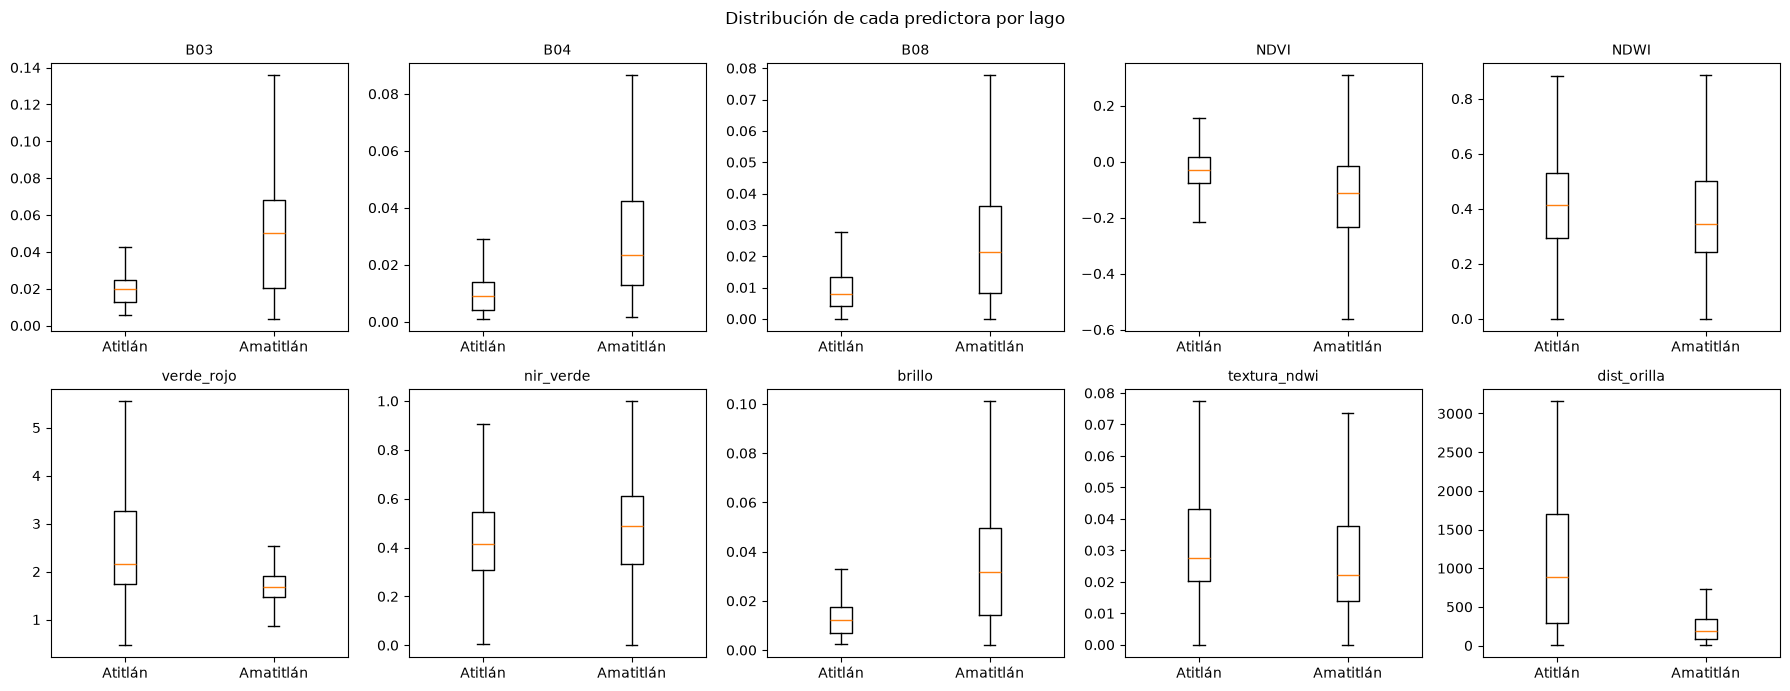

In [20]:
fig, ejes = plt.subplots(2, 5, figsize=(18, 7), sharey=False)
for eje, col in zip(ejes.ravel(), PREDICTORES):
    datos = [ml.loc[ml["lago"] == lago, col].dropna() for lago in ["Atitlan", "Amatitlan"]]
    eje.boxplot(datos, tick_labels=["Atitlán", "Amatitlán"], showfliers=False)
    eje.set_title(col, fontsize=10)
fig.suptitle("Distribución de cada predictora por lago")
plt.tight_layout()
plt.savefig("figuras/comparacion_predictores_lagos.png", dpi=150, bbox_inches="tight")
plt.show()

La causa de fondo es que los dos lagos no comparten ni la prevalencia de la clase ni la escala de las
variables espectrales, así que un umbral de decisión aprendido en uno queda mal calibrado en el otro.

- **Prevalencia:** 39.94% de los píxeles de Amatitlán son de alta presencia contra apenas 1.10% en Atitlán, una
  proporción casi 36 veces mayor. Un modelo entrenado en Atitlán aprende a predecir positivo muy pocas veces, lo
  que en Amatitlán se traduce en recall bajísimo; un modelo entrenado en Amatitlán aprende a predecir positivo con
  frecuencia, lo que en Atitlán se traduce en precisión bajísima.
- **Nivel de reflectancia:** B03, B04, B08 y brillo son entre 2.3 y 2.7 veces más altos en promedio en Amatitlán
  que en Atitlán (por ejemplo B03 pasa de 0.0205 a 0.0477). Como estas cuatro variables son justamente las que más
  separan las clases dentro de cada lago, un valor que en Amatitlán es apenas moderado puede ser, en la escala de
  Atitlán, uno de los más altos jamás observado, y viceversa.
- **Distancia a la orilla:** el promedio es de 1058 m en Atitlán contra 240 m en Amatitlán, casi 4.4 veces mayor,
  simple reflejo de que Atitlán es un lago mucho más extenso. `dist_orilla` fue la variable geográfica más
  informativa dentro de cada lago, pero un valor de "cerca de la orilla" en un lago corresponde a un valor de
  "relativamente lejos" en el otro, así que el umbral que el modelo aprende no es transferible.
- **Tamaño, profundidad y eutrofización:** como ya se estableció en la Parte I, Amatitlán es un lago pequeño y
  somero (unos 15 km²) que recibe la descarga del río Villalobos con aguas residuales de la cuenca metropolitana
  sin tratar, lo que lo mantiene en estado hipereutrófico (clorofila-a promedio de 12.5 ug/L); Atitlán es un lago
  profundo de origen volcánico, con más de cien kilómetros cuadrados de superficie, que diluye cualquier aporte de
  nutrientes en un volumen mucho mayor y se mantiene oligotrófico (clorofila-a promedio de 3.5 ug/L). Son, en la
  práctica, dos poblaciones estadísticas distintas, y el modelo entrenado en una no tiene forma de conocer la escala
  de la otra.

En conjunto, esto confirma que la floración de cianobacterias en estos dos lagos no comparte una firma espectral
única y portable: depende del régimen de nutrientes propio de cada cuerpo de agua. Un sistema operativo de alerta
temprana necesitaría un modelo o al menos un umbral calibrado por lago, no un modelo entrenado en uno y aplicado
directamente al otro.

In [21]:
resultados_espacial.to_csv("resultados_espacial.csv", index=False)
resultados_temporal.to_csv("resultados_temporal.csv", index=False)
resultados_generalizacion.to_csv("resultados_generalizacion.csv", index=False)
tabla_comparativa.to_csv("tabla_comparativa_validacion.csv")
comparacion_predictores.to_csv("comparacion_predictores_lagos.csv")
print("Resultados de incisos 6 y 7 guardados en CSV")

Resultados de incisos 6 y 7 guardados en CSV
